# MSDS 466 Final Project
# Generative AI For Named Entity Recognition

Soraya Ashley Karimi Butler
06/07/2026

Using the MIT Movie Reviews NER dataset and the llmer library for prompt development, this project will compare the performance of zero-shot, one-shot, few-shot, and chain-of-thought.




## Resources

We will use the `llmner` library from GitHub for prompting and calling the OpenAI API. First, let's install it.

In [ ]:
# Install the llmner library from GitHub
# ! pip install git+https://github.com/plncmm/llmner.git

### Description of `llmner` library, `AnnotatedDocument`, and `Annotations`

The `llmner` library (Language Model for Named Entity Recognition) is designed to facilitate Named Entity Recognition (NER) tasks using Large Language Models (LLMs). It likely provides utilities for preparing data, structuring prompts for LLMs, parsing LLM responses into structured annotations, and potentially evaluating NER performance.

Within this library, `AnnotatedDocument` and `Annotations` are likely core data structures:

*   **`AnnotatedDocument`**: This class probably represents a document or a piece of text that has been or is intended to be annotated with named entities. It would typically hold the raw text content, and possibly metadata related to the document. It serves as the primary container for the text upon which NER is performed.

*   **`Annotations`**: This class, or a similar structure, would be responsible for storing the actual named entity annotations extracted from an `AnnotatedDocument`. It would likely contain a collection of individual entity mentions, each specifying:
    *   The **text span** (e.g., start and end character offsets).
    *   The **entity text** itself.
    *   The **entity type** (e.g., 'PERSON', 'ORGANIZATION', 'LOCATION').
    *   Potentially other attributes like confidence scores or links to knowledge bases.

# Imports

In [125]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

from datasets import load_dataset
from llmner.data import AnnotatedDocument, Annotation, AnnotatedDocumentWithException

from google.colab import userdata
from llmner import ZeroShotNer, FewShotNer

import os

import spacy
from spacy.scorer import Scorer
from spacy.tokens import Doc
from spacy.training import Example
from spacy.training import offsets_to_biluo_tags

from sklearn.metrics import confusion_matrix, classification_report

import pickle



In [2]:
# mount colab drive
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


# Loading `tner/mit_movie_trivia` Dataset from Hugging Face

### Dataset Details: IOB Tagging and Entity Types

This dataset uses the **IOB (Inside, Outside, Beginning) tagging scheme** for Named Entity Recognition.

*   **B-**: Indicates the beginning of an entity.
*   **I-**: Indicates that the token is inside an entity (i.e., a continuation of a multi-token entity).
*   **O**: Indicates that the token is outside of any entity.

For example, if 'Michael Douglas' is tagged as an Actor, 'Michael' would be 'B-Actor' and 'Douglas' would be 'I-Actor'.

**Entities in this dataset (`tner/mit_movie_trivia`):**

The dataset includes the following entity types and their corresponding IOB tags:

*   **O** (Outside of an entity)
*   **B-Actor**, **I-Actor**
*   **B-Plot**, **I-Plot**
*   **B-Opinion**, **I-Opinion**
*   **B-Award**, **I-Award**
*   **B-Year**, **I-Year**
*   **B-Genre**, **I-Genre**
*   **B-Origin**, **I-Origin**
*   **B-Director**, **I-Director**
*   **B-Soundtrack**, **I-Soundtrack**
*   **B-Relationship**, **I-Relationship**
*   **B-Character_Name**, **I-Character_Name**
*   **B-Quote**, **I-Quote**

**Dataset Summary:**

*   **Training Set:** 6816 examples
*   **Testing Set:** 1953 examples

In [ ]:
# # Install the datasets library
# !pip install "datasets<=3.6.0"

In [3]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("tner/mit_movie_trivia")

print("Dataset loaded successfully:")
print(dataset)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset loaded successfully:
DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 6816
    })
    validation: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 1953
    })
})


In [4]:
# Entity Mapping
tag_mapper = {
    "O": 0,
    "B-Actor": 1,
    "I-Actor": 2,
    "B-Plot": 3,
    "I-Plot": 4,
    "B-Opinion": 5,
    "I-Opinion": 6,
    "B-Award": 7,
    "I-Award": 8,
    "B-Year": 9,
    "B-Genre": 10,
    "B-Origin": 11,
    "I-Origin": 12,
    "B-Director": 13,
    "I-Director": 14,
    "I-Genre": 15,
    "I-Year": 16,
    "B-Soundtrack": 17,
    "I-Soundtrack": 18,
    "B-Relationship": 19,
    "I-Relationship": 20,
    "B-Character_Name": 21,
    "I-Character_Name": 22,
    "B-Quote": 23,
    "I-Quote": 24
}

### Dataset Structure and First Example

In [5]:
dataset["train"][0]

{'tokens': ['what',
  '1995',
  'romantic',
  'comedy',
  'film',
  'starred',
  'michael',
  'douglas',
  'as',
  'a',
  'u',
  's',
  'head',
  'of',
  'state',
  'looking',
  'for',
  'love'],
 'tags': [0, 9, 10, 15, 0, 0, 1, 2, 0, 3, 4, 4, 4, 4, 4, 4, 4, 4]}

In [6]:
# Print the first example from the training split to inspect its structure
first_example = dataset['train'][0]
print("First example from the training split:")
print(first_example)

# Check if the length of 'tokens' matches the length of 'ner_tags'
tokens = first_example['tokens']
ner_tags = first_example['tags']

print(f"\nLength of tokens: {len(tokens)}")
print(f"Length of ner_tags: {len(ner_tags)}")

if len(tokens) == len(ner_tags):
    print("The length of the tokens list matches the length of the tags list. This indicates consistent word-level tagging.")
else:
    print("WARNING: The length of the tokens list DOES NOT match the length of the tags list.")

First example from the training split:
{'tokens': ['what', '1995', 'romantic', 'comedy', 'film', 'starred', 'michael', 'douglas', 'as', 'a', 'u', 's', 'head', 'of', 'state', 'looking', 'for', 'love'], 'tags': [0, 9, 10, 15, 0, 0, 1, 2, 0, 3, 4, 4, 4, 4, 4, 4, 4, 4]}

Length of tokens: 18
Length of ner_tags: 18
The length of the tokens list matches the length of the tags list. This indicates consistent word-level tagging.


### Inspecting Token-Tag Pairs

In [7]:
# To make the tags human-readable, we will use the provided tag_mapper from cell L6TJeGs60N_9
# Create a reverse mapping from tag ID to tag name
reverse_tag_mapper = {v: k for k, v in tag_mapper.items()}

print("\nSample Token-Tag Pairs (First 3 items):")
for i in range(min(3, len(tokens))):
    token = tokens[i]
    tag_id = ner_tags[i]
    tag_name = reverse_tag_mapper.get(tag_id, f"UNKNOWN_TAG_ID_{tag_id}")
    print(f"  Token: '{token}', Tag: '{tag_name}'")

print("\nSample Token-Tag Pairs (Last 3 items, if available):")
if len(tokens) > 3:
    for i in range(len(tokens) - 3, len(tokens)):
        token = tokens[i]
        tag_id = ner_tags[i]
        tag_name = reverse_tag_mapper.get(tag_id, f"UNKNOWN_TAG_ID_{tag_id}")
        print(f"  Token: '{token}', Tag: '{tag_name}'")
else:
    print("Not enough tokens to display last 3 items separately.")


Sample Token-Tag Pairs (First 3 items):
  Token: 'what', Tag: 'O'
  Token: '1995', Tag: 'B-Year'
  Token: 'romantic', Tag: 'B-Genre'

Sample Token-Tag Pairs (Last 3 items, if available):
  Token: 'looking', Tag: 'I-Plot'
  Token: 'for', Tag: 'I-Plot'
  Token: 'love', Tag: 'I-Plot'


### Dataset Shape

In [8]:
print(f"Training set shape: {dataset['train'].num_rows} examples")
print(f"Testing set shape: {dataset['test'].num_rows} examples")

Training set shape: 6816 examples
Testing set shape: 1953 examples


### Entity Tag Distribution Analysis

Understanding the distribution of named entity tags is crucial for NER tasks, as it can highlight class imbalances and the prevalence of different entity types. This analysis will visualize the frequency of each tag in the training dataset.

/tmp/ipykernel_36534/2405712071.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Tag', data=df_tag_distribution, palette='viridis')


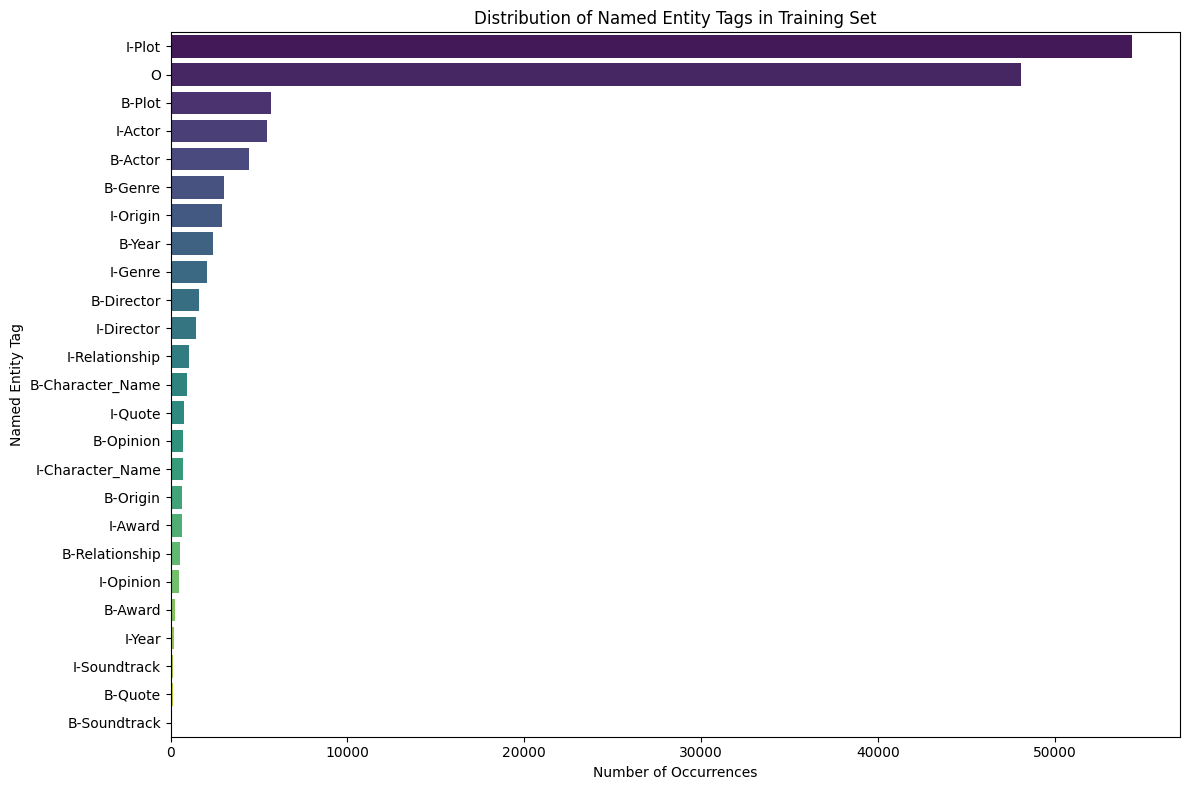

In [9]:
# Flatten the list of all tags from the training set
all_tags = [tag for example in dataset['train'] for tag in example['tags']]

# Count the occurrences of each tag ID
tag_counts = Counter(all_tags)

# Map tag IDs to their human-readable names using reverse_tag_mapper
tag_names = [reverse_tag_mapper.get(tag_id, f"UNKNOWN_TAG_ID_{tag_id}") for tag_id in tag_counts.keys()]
counts = list(tag_counts.values())

# Create a DataFrame for easier plotting with seaborn
import pandas as pd
df_tag_distribution = pd.DataFrame({'Tag': tag_names, 'Count': counts})

# Sort by count for better visualization
df_tag_distribution = df_tag_distribution.sort_values(by='Count', ascending=False)

# Plot the distribution
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Tag', data=df_tag_distribution, palette='viridis')
plt.title('Distribution of Named Entity Tags in Training Set')
plt.xlabel('Number of Occurrences')
plt.ylabel('Named Entity Tag')
plt.tight_layout()
plt.show()

### Token Count Statistics

This analysis will provide insights into the length of token sequences in the training dataset, including the minimum, maximum, average, and standard deviation of token counts per example.

In [12]:
# Get the length of token lists for each example in the training set
token_lengths = [len(example['tokens']) for example in dataset['train']]

# Calculate statistics
min_tokens = np.min(token_lengths)
max_tokens = np.max(token_lengths)
mean_tokens = np.mean(token_lengths)
std_tokens = np.std(token_lengths)

print(f"Token Count Statistics (Training Set):\n")
print(f"  Minimum tokens per example: {min_tokens}")
print(f"  Maximum tokens per example: {max_tokens}")
print(f"  Average tokens per example: {mean_tokens:.2f}")
print(f"  Standard deviation of tokens per example: {std_tokens:.2f}")

Token Count Statistics (Training Set):

  Minimum tokens per example: 3
  Maximum tokens per example: 71
  Average tokens per example: 20.31
  Standard deviation of tokens per example: 5.55


### Sentence Length Distribution

This visualization will show the distribution of the number of tokens per example in the training set, helping to understand the typical 'sentence' length in the dataset.

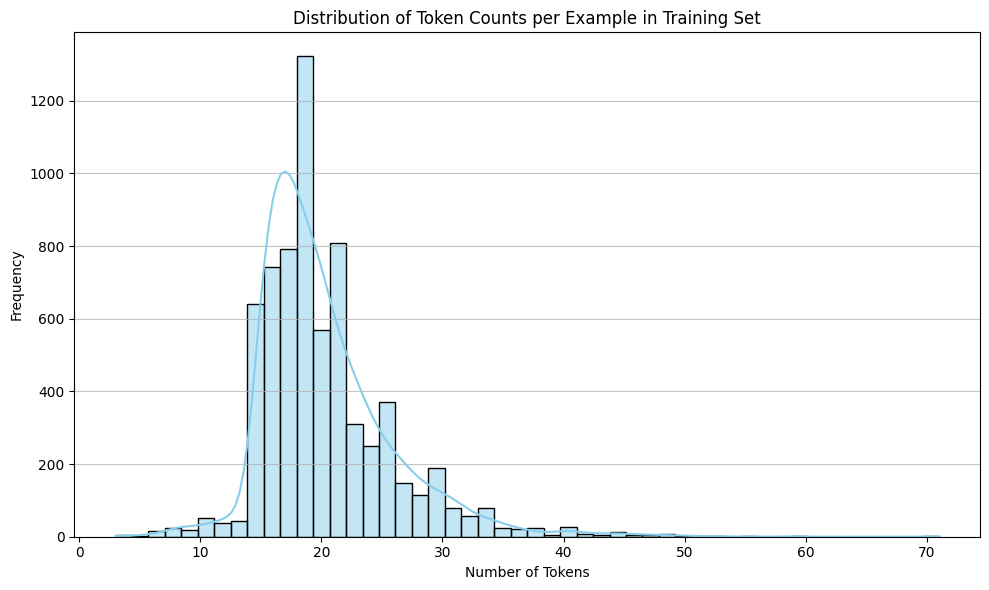

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(token_lengths, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Token Counts per Example in Training Set')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Prompt Development with `llmner`

This section will demonstrate how to develop prompts using the `llmner` library, specifically focusing on its `AnnotatedDocument` and `Annotation` classes.

### MIT Movie Entities Dictionary

First, let's create an `entities` dictionary that describes each of the MIT Movie entities. This will be useful when constructing prompts for the LLM.

In [14]:
# Extract unique base entity types from the reverse_tag_mapper
# Filter out 'O' (Outside) and 'I-' (Inside) tags to get base entity types
base_entity_types = sorted(list(set([tag.replace('B-', '').replace('I-', '') for tag in reverse_tag_mapper.values() if tag != 'O']))) # 'reverse_tag_mapper' should be available from previous cells

entities_descriptions = {
    'Actor': 'The name of an actor or actress.',
    'Award': 'A specific award, prize, or nomination.',
    'Character_Name': 'The name of a character in a movie.',
    'Director': 'The name of a movie director.',
    'Genre': 'A category or style of movie (e.g., action, drama, comedy).',
    'Opinion': 'An expressed sentiment or review about a movie.',
    'Origin': 'The country or region of origin for a movie or person.',
    'Plot': 'A description or summary of the movie\'s storyline.',
    'Quote': 'A direct quotation from a movie.',
    'Relationship': 'A relationship between entities (e.g., actors, characters).',
    'Soundtrack': 'Information about a movie\'s musical score or songs.',
    'Year': 'A specific year related to a movie\'s release or production.'
}

# Filter the descriptions to only include entities actually present in our dataset
mit_movie_entities = {k: v for k, v in entities_descriptions.items() if k in base_entity_types}

print("MIT Movie Entities Dictionary:")
for entity_type, description in mit_movie_entities.items():
    print(f"- {entity_type}: {description}")

MIT Movie Entities Dictionary:
- Actor: The name of an actor or actress.
- Award: A specific award, prize, or nomination.
- Character_Name: The name of a character in a movie.
- Director: The name of a movie director.
- Genre: A category or style of movie (e.g., action, drama, comedy).
- Opinion: An expressed sentiment or review about a movie.
- Origin: The country or region of origin for a movie or person.
- Plot: A description or summary of the movie's storyline.
- Quote: A direct quotation from a movie.
- Relationship: A relationship between entities (e.g., actors, characters).
- Soundtrack: Information about a movie's musical score or songs.
- Year: A specific year related to a movie's release or production.


### Utility Function: `create_annotated_document_from_tokens_and_tags`

The `mit_movie_trivia` dataset provides `tokens` (words) and `tags` (IOB scheme), while the `llmner` library's `Annotation` objects require character `start` and `end` indices. This utility function will bridge that gap by reconstructing the full text and calculating the precise character offsets for each entity based on the IOB tags.

In [33]:
def create_annotated_document_from_tokens_and_tags(
    tokens: list[str],
    tags: list[int],
    reverse_tag_mapper: dict
) -> AnnotatedDocument:
    """
    Converts token-level annotations (tokens and IOB tags) into a character-level
    AnnotatedDocument object.

    Args:
        tokens (list[str]): A list of tokens (words).
        tags (list[int]): A list of corresponding IOB tag IDs.
        reverse_tag_mapper (dict): A mapping from tag IDs to human-readable tag names.

    Returns:
        AnnotatedDocument: An AnnotatedDocument object with character-level annotations.
    """
    full_text = []
    char_offsets = []
    current_offset = 0

    for token in tokens:
        full_text.append(token)
        char_offsets.append(current_offset)
        current_offset += len(token)
        # Add space after each token for reconstruction, except the last one
        if token != tokens[-1]:
            full_text.append(' ')
            current_offset += 1

    text_str = "".join(full_text)
    annotations = set()

    current_entity_start_char = -1
    current_entity_label = None
    current_entity_start_token_idx = -1

    for i, (token, tag_id) in enumerate(zip(tokens, tags)):
        tag_name = reverse_tag_mapper[tag_id]

        # Handle 'B-' (Beginning of an entity)
        if tag_name.startswith('B-'):
            # If a previous entity was active, finalize it
            if current_entity_label is not None:
                end_char = char_offsets[i - 1] + len(tokens[i - 1])
                annotations.add(Annotation(
                    current_entity_start_char, end_char, current_entity_label
                ))

            # Start new entity
            current_entity_start_char = char_offsets[i]
            current_entity_label = tag_name[2:]  # Remove 'B-'
            current_entity_start_token_idx = i

        # Handle 'I-' (Inside an entity)
        elif tag_name.startswith('I-'):
            # Ensure 'I-' tag correctly follows a 'B-' or 'I-' of the same type
            if current_entity_label is not None and tag_name[2:] == current_entity_label:
                # Continue the current entity, nothing to do yet except update indices
                pass
            else:
                # Invalid IOB sequence or mismatch: treat as a new entity or 'O'
                # For robustness, we'll finalize any active entity and then treat this 'I-' as an 'O' for now.
                if current_entity_label is not None:
                    end_char = char_offsets[i - 1] + len(tokens[i - 1])
                    annotations.add(Annotation(
                        current_entity_start_char, end_char, current_entity_label
                    ))
                current_entity_label = None # Reset, effectively treating as 'O'
                current_entity_start_char = -1
                current_entity_start_token_idx = -1

        # Handle 'O' (Outside of an entity)
        elif tag_name == 'O':
            # If an entity was active, finalize it
            if current_entity_label is not None:
                end_char = char_offsets[i - 1] + len(tokens[i - 1])
                annotations.add(Annotation(
                    current_entity_start_char, end_char, current_entity_label
                ))
            current_entity_label = None
            current_entity_start_char = -1
            current_entity_start_token_idx = -1

    # After loop, finalize any remaining active entity
    if current_entity_label is not None:
        end_char = char_offsets[len(tokens) - 1] + len(tokens[len(tokens) - 1])
        annotations.add(Annotation(
            current_entity_start_char, end_char, current_entity_label
        ))

    return AnnotatedDocument(text_str, list(annotations))

### Demonstrating `create_annotated_document_from_tokens_and_tags`

Now, let's use this new utility function with our first example from the `mit_movie_trivia` training set (`dataset['train'][0]`) to create an `AnnotatedDocument`.

In [34]:
# Use the first example from the training set
first_example_data = dataset['train'][0]
example_tokens = first_example_data['tokens']
example_tags = first_example_data['tags']

# Create the AnnotatedDocument
annotated_doc_from_dataset = create_annotated_document_from_tokens_and_tags(
    example_tokens, example_tags, reverse_tag_mapper
)

print("\n--- Annotated Document from Dataset Example ---")
print(f"Reconstructed Text: '{annotated_doc_from_dataset.text}'")
print(f"Annotations: {annotated_doc_from_dataset.annotations}")

# You can verify extracted text for each annotation:
print("\nVerified Extracted Text for Annotations:")
for ann in annotated_doc_from_dataset.annotations:
    extracted_text = annotated_doc_from_dataset.text[ann.start:ann.end]
    print(f"  Label: {ann.label}, Start: {ann.start}, End: {ann.end}, Extracted: '{extracted_text}'")


--- Annotated Document from Dataset Example ---
Reconstructed Text: 'what 1995 romantic comedy film starred michael douglas as a u s head of state looking for love'
Annotations: [Annotation(start=58, end=94, label='Plot', text=None), Annotation(start=10, end=25, label='Genre', text=None), Annotation(start=5, end=9, label='Year', text=None), Annotation(start=39, end=54, label='Actor', text=None)]

Verified Extracted Text for Annotations:
  Label: Plot, Start: 58, End: 94, Extracted: 'a u s head of state looking for love'
  Label: Genre, Start: 10, End: 25, Extracted: 'romantic comedy'
  Label: Year, Start: 5, End: 9, Extracted: '1995'
  Label: Actor, Start: 39, End: 54, Extracted: 'michael douglas'


### Exploring `llmner.utils` for Prompt Generation

The `llmner` library provides several utility functions to directly generate prompt strings for different few-shot learning scenarios, rather than relying solely on a `PromptBuilder` class for all formats. Let's explore these functions:

*   `annotated_document_to_json_annotated_string`: Converts an `AnnotatedDocument` into a JSON string representation, which can be useful for structured prompting.
*   `annotated_document_to_single_turn_few_shot_example`: Generates a single-turn few-shot example string from an `AnnotatedDocument`.
*   `annotated_document_to_multi_turn_few_shot_example`: Generates a multi-turn (user/assistant) few-shot example string from an `AnnotatedDocument`.

The code for actual prompt generation appears is complex, and there is not explicit rule stated by the authors. I've pasted the prompt template below as an indication for how data would be passed to the LLM.

TEMPLATE_EN = PromptTemplate(
    inline_single_turn="""You are a named entity recognizer that must detect the next entities:
{entities}
You must answer with the same input text, but with the named entities annotated with in-line tag annotations (<entity>text</entity>), where each tag corresponds to an entity name, for example: <name>John Doe</name> is the owner of <organization>ACME</organization>.
The only available tags are: {entity_list}, you cannot add more tags than the included in that list.
IMPORTANT: YOU SHOULD NOT CHANGE THE INPUT TEXT, ONLY ADD THE TAGS.""",
    inline_multi_turn_default_delimiters="""You are a named entity recognizer that must detect the next entities:
{entities}
You must answer with the same input text, but with a single entity annotated with in-line tag annotations (<entity>text</entity>), where the tag corresponds to an entity name, for example, first I ask you to annotate names: <name>John Doe</name> is the owner of ACME and then I ask you to annotate organizations: John Doe is the owner of <organization>ACME</organization>.
The only available tags are: {entity_list}, you cannot add more tags than the included in that list.
IMPORTANT: YOU SHOULD NOT CHANGE THE INPUT TEXT, ONLY ADD THE TAGS""",
    inline_multi_turn_custom_delimiters="""You are a named entity recognizer that must detect the next entities:
{entities}
You must answer with the same input text, but with a single entity annotated with in-line tag annotations ({start_token}text{end_token}), where the tag corresponds to an entity name, for example, first I ask you to annotate names: {start_token}Jhon Doe{end_token} is the owner of ACME and then I ask you to annotate organizations: John Doe is the owner of {start_token}ACME{end_token}.
The only available tags are: {entity_list}, you cannot add more tags than the included in that list.
IMPORTANT: YOU SHOULD NOT CHANGE THE INPUT TEXT, ONLY ADD THE TAGS""",
    json_single_turn="""You are a named entity recognizer that must detect the next entities:
{entities}
You must answer with JSON format, where each key corresponds to an entity class, and the value is a list of the entity mentions, for example: {{"name": ["John Doe"], "organization": ["ACME"]}}.
The only available tags are: {entity_list}, you cannot add more tags than the included in that list.
IMPORTANT:  YOUR OUTPUT SHOULD ONLY BE A JSON IN THE FORMAT {{"entity_class": ["entity_mention_1", "entity_mention_2"]}}. NO OTHER FORMAT IS ALLOWED.""",
    json_multi_turn="""You are a named entity recognizer that must detect the next entities:
{entities}
You must answer with the same input text, but with a single entity annotated with JSON format, where the key corresponds to an entity class  for example, first I ask you to annotate names: {{"name": ["John Doe"]}} and then I ask you to annotate organizations: {{"organization": ["ACME"]}}
The only available tags are: {entity_list}, you cannot add more tags than the included in that list.
IMPORTANT: YOUR OUTPUT SHOULD ONLY BE A JSON IN THE FORMAT {{"entity_class": ["entity_mention_1", "entity_mention_2"]}}. NO OTHER FORMAT IS ALLOWED.""",
    multi_turn_prefix="""In the next text, annotate the entity """,
    pos="""You are a part-of-speech tagger that must detect part-of-speech tags. Respond with the same input text, but with the part-of-speech tags after each word, for example: John/NNP Doe/NNP is/VBZ the/DT owner/NN of/IN ACME/NNP.""",
    pos_answer_prefix="""This is the text with the part-of-speech tags:""",
    final_message_prefix= """Now, annotate the next document with all entities ({entity_list}):"""
)

In [35]:
from llmner.utils import (
    annotated_document_to_json_annotated_string,
    annotated_document_to_single_turn_few_shot_example,
    annotated_document_to_multi_turn_few_shot_example
)

# 1. Demonstrate annotated_document_to_json_annotated_string
print("\n--- JSON Annotated String Example ---")
json_string = annotated_document_to_json_annotated_string(annotated_doc_from_dataset)
print(json_string)


--- JSON Annotated String Example ---
{"Plot": ["a u s head of state looking for love"], "Genre": ["romantic comedy"], "Year": ["1995"], "Actor": ["michael douglas"]}


In [36]:
# 2. Demonstrate annotated_document_to_single_turn_few_shot_example
print("\n--- Single-Turn Few-Shot Example ---")
single_turn_example = annotated_document_to_single_turn_few_shot_example(
    annotated_doc_from_dataset
)
print(single_turn_example)


--- Single-Turn Few-Shot Example ---
{'input': 'what 1995 romantic comedy film starred michael douglas as a u s head of state looking for love', 'output': 'what <Year>1995</Year> <Genre>romantic comedy</Genre> film starred <Actor>michael douglas</Actor> as <Plot>a u s head of state looking for love</Plot>'}


# Test LLMNER functionality - Zero Shot

Replicating examples from the LLMNER readme to get a feel for the functionality, using MIT Movie Reviews samples.

For cost purposes, will opt to use GPT-4.1-mini.

In [55]:
# Set the secret as an environment variable
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [56]:
model = ZeroShotNer(model="gpt-4.1-mini")
model.contextualize(entities=entities_descriptions)

In [57]:
# zero shot prediction
example_for_prediction = single_turn_example["input"]
example_for_prediction

'what 1995 romantic comedy film starred michael douglas as a u s head of state looking for love'

In [59]:
# response = model.predict([example_for_prediction])

100%|██████████| 1/1 [00:01<00:00,  1.89s/ example]


In [65]:
response

[AnnotatedDocumentWithException(text='what 1995 romantic comedy film starred michael douglas as a u s head of state looking for love', annotations={Annotation(start=10, end=25, label='Genre', text='romantic comedy'), Annotation(start=5, end=9, label='Year', text='1995')}, exception=NotPerfectlyAlignedError('The text cannot be perfectly aligned'))]

In [64]:
#  a list of LLMNER class types
type(response[0])

llmner.data.AnnotatedDocumentWithException

# Evaluating NER Accuracy with `spacy.scorer`

Now that we have functions to generate `AnnotatedDocument` objects from our dataset and process LLM predictions, let's create a utility to evaluate the accuracy of these predictions using `spacy.scorer`. This function will take a ground truth `AnnotatedDocument` and a predicted `AnnotatedDocument` (or `AnnotatedDocumentWithException`), convert their annotations to a spaCy-compatible format, and then compute Precision, Recall, and F1-score.

In [129]:
import spacy
from spacy.scorer import Scorer
from spacy.training import Example
from spacy.tokens import Doc
from spacy.util import filter_spans
from llmner.data import Annotation, AnnotatedDocument, AnnotatedDocumentWithException

# Load a blank spaCy model for tokenization (scorer needs a Doc object)
nlp = spacy.blank("en")

def convert_llmner_annotations_to_spacy_format(doc_obj: AnnotatedDocument) -> dict:
    """
    Converts Annotations from an AnnotatedDocument to spaCy's entity format.
    """
    entities = []
    for ann in doc_obj.annotations:
        # Ensure start and end are integers
        start = int(ann.start)
        end = int(ann.end)
        label = ann.label
        entities.append((start, end, label))
    return {"entities": entities}

def create_ner_examples_for_spacy_scorer(
    ground_truth_docs: list[AnnotatedDocument],
    predicted_docs: list[AnnotatedDocument | AnnotatedDocumentWithException]
) -> list[Example]:
    """
    Creates a list of spaCy Example objects from ground truth and predicted AnnotatedDocument objects.
    """
    if len(ground_truth_docs) != len(predicted_docs):
        raise ValueError("The number of ground truth documents must match the number of predicted documents.")

    examples = []
    for ground_truth_doc, predicted_doc_item in zip(ground_truth_docs, predicted_docs):
        # Ensure predicted_doc_item is an AnnotatedDocument if it's AnnotatedDocumentWithException
        if isinstance(predicted_doc_item, AnnotatedDocumentWithException):
            if predicted_doc_item.exception is not None:
                print(f"Warning: Predicted document contains an exception: {predicted_doc_item.exception}")
            # Convert AnnotatedDocumentWithException to AnnotatedDocument for consistent processing
            predicted_doc = AnnotatedDocument(predicted_doc_item.text, predicted_doc_item.annotations)
        else:
            predicted_doc = predicted_doc_item

        if ground_truth_doc.text != predicted_doc.text:
            raise ValueError("Text content of ground truth and predicted documents do not match.")

        # Convert annotations to spaCy dict format
        gold_annot_dict = convert_llmner_annotations_to_spacy_format(ground_truth_doc)
        pred_annot_dict = convert_llmner_annotations_to_spacy_format(predicted_doc)

        # Create spaCy Doc object for the predicted document
        # Use nlp.make_doc to create a Doc object without running a full pipeline
        doc_pred = nlp.make_doc(predicted_doc.text)

        # Manually set the predicted entities on the predicted doc
        ents = []
        for start, end, label in pred_annot_dict["entities"]:
            # Use doc_pred.char_span to correctly create Span objects
            span = doc_pred.char_span(start, end, label=label, alignment_mode="contract")
            if span is not None:
                ents.append(span)
        doc_pred.ents = filter_spans(ents) # Set the predicted entities on the Doc (filtering overlaps)

        # Create the Example object
        # Example.from_dict expects the predicted Doc (with entities set)
        # and a dictionary for the gold-standard annotations.
        example = Example.from_dict(doc_pred, gold_annot_dict)
        examples.append(example)

    return examples

def score_ner_examples(examples: list[Example]):
    """
    Scores a list of spaCy Example objects for NER accuracy.

    Args:
        examples (list[Example]): A list of spaCy Example objects to be scored.
    """
    scorer = Scorer()
    scores = scorer.score(examples)

    print(f"\n--- NER Evaluation Results ---")
    print(f"Precision: {scores['ents_p']:.2f}")
    print(f"Recall: {scores['ents_r']:.2f}")
    print(f"F1 Score: {scores['ents_f']:.2f}")

    return scores

### Example Usage of `evaluate_ner_accuracy`

Let's use the `annotated_doc_from_dataset` as our `ground_truth_doc` and the `response[0]` (which is the output from our `ZeroShotNer` model) as our `predicted_doc` to demonstrate the new evaluation function.

In [130]:
# Assuming `annotated_doc_from_dataset` is our ground truth (created earlier)
# And `response` is our list of predictions from the ZeroShotNer model

# 1. Create the Example objects
ner_examples = create_ner_examples_for_spacy_scorer(
    ground_truth_docs=[annotated_doc_from_dataset],
    predicted_docs=[response[0]]
)

print("\n--- Example Object for Scorer ---")
for i, example in enumerate(ner_examples):
    print(f"Example {i+1}:")
    print(example)

# 2. Call the scoring function with the list of examples
evaluation_scores = score_ner_examples(
    examples=ner_examples
)


--- Example Object for Scorer ---
Example 1:
{'doc_annotation': {'cats': {}, 'entities': ['O', 'U-Year', 'B-Genre', 'L-Genre', 'O', 'O', 'B-Actor', 'L-Actor', 'O', 'B-Plot', 'I-Plot', 'I-Plot', 'I-Plot', 'I-Plot', 'I-Plot', 'I-Plot', 'I-Plot', 'L-Plot'], 'spans': {}, 'links': {}}, 'token_annotation': {'ORTH': ['what', '1995', 'romantic', 'comedy', 'film', 'starred', 'michael', 'douglas', 'as', 'a', 'u', 's', 'head', 'of', 'state', 'looking', 'for', 'love'], 'SPACY': [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False], 'TAG': ['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], 'LEMMA': ['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], 'POS': ['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], 'MORPH': ['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', ''], 'HEAD': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], 'DEP': ['', '', '

# NER Token-Level Confusion Matrix Development

### Entity-Level vs. Token-Level Evaluation

*   **Entity-Level (`spacy.scorer`)**: Evaluates the exact match of the entire entity span. If the true entity is "Michael Douglas" (Actor) and the model predicts only "Douglas" or gets the boundaries slightly wrong, it counts as a completely missed entity (False Negative) and a wrong prediction (False Positive).
*   **Token-Level (Confusion Matrix)**: Evaluates the classification of each individual word (token). For "Michael Douglas", "Michael" is `B-Actor` and "Douglas" is `L-Actor`. This gives a more granular view of where errors occur (e.g., misclassifying an inside token `I-Plot` as outside `O`), and doesn't penalize a partially correct entity as severely.

To get a more detailed view of where the model's predictions go wrong, we'll create a token-level confusion matrix. This matrix will show which specific BILOU (Beginning, Inside, Last, Unit, Outside) tags are being confused with others.

We will use `spacy.training.iob_utils.offsets_to_bilou_tags` to convert character-level annotations into token-level BILOU tags, and then `sklearn.metrics.confusion_matrix` to build the matrix.

In [117]:
def calculate_ner_confusion_matrix(examples: list[Example]):
    """
    Calculates and visualizes a token-level confusion matrix for NER predictions,
    stripping the BILOU prefixes for easier readability.

    Args:
        examples (list[Example]): A list of spaCy Example objects.
    """
    from sklearn.metrics import ConfusionMatrixDisplay

    def strip_prefix(tag):
        return tag.split('-', 1)[1] if '-' in tag else tag

    raw_y_true = []
    raw_y_pred = []

    for example in examples:
        doc_gold = example.reference
        doc_pred = example.predicted

        # Extract entities as (start_char, end_char, label) for offsets_to_bilou_tags
        gold_entities = [(ent.start_char, ent.end_char, ent.label_) for ent in doc_gold.ents]
        pred_entities = [(ent.start_char, ent.end_char, ent.label_) for ent in doc_pred.ents]

        # Extract BILOU tags for ground truth
        gold_bilou_tags = offsets_to_biluo_tags(doc_gold, gold_entities)
        # Extract BILOU tags for predictions
        pred_bilou_tags = offsets_to_biluo_tags(doc_pred, pred_entities)

        # Ensure lengths match and append, filtering out any potential misalignment tokens ('-')
        if len(gold_bilou_tags) != len(pred_bilou_tags):
            print(f"Warning: Token count mismatch between gold and predicted for text: {doc_gold.text}. Skipping for confusion matrix.")
            continue

        for g, p in zip(gold_bilou_tags, pred_bilou_tags):
            # Append all tags assuming consistent tokenization and alignment handled by spaCy's utilities.
            raw_y_true.append(g)
            raw_y_pred.append(p)

    # Strip the BILOU prefixes to group by base entity type
    y_true = [strip_prefix(t) for t in raw_y_true]
    y_pred = [strip_prefix(t) for t in raw_y_pred]

    # Compute Confusion Matrix
    labels = sorted(list(set(y_true + y_pred)))

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    print("\n--- NER Token-Level Confusion Matrix Results ---")
    print("Labels (Base Entity Types):", labels)
    print("Confusion Matrix:\n", cm)

    # Classification Report provides Precision, Recall, F1 for each tag
    print("\nClassification Report (Token-Level, Base Entities):\n")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    # Use ConfusionMatrixDisplay which guarantees proper axis label alignment
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title('spaCy NER Token-Level Confusion Matrix (Base Entities)')
    plt.tight_layout()
    plt.show()

### Example Usage of Confusion Matrix Calculation

Let's test the `calculate_ner_confusion_matrix` function using the `ner_examples` we generated earlier from our single test case. This will demonstrate its functionality before we apply it to a larger set of predictions.


--- NER Token-Level Confusion Matrix Results ---
Labels (Base Entity Types): ['Actor', 'Genre', 'O', 'Plot', 'Year']
Confusion Matrix:
 [[0 0 2 0 0]
 [0 2 0 0 0]
 [0 0 4 0 0]
 [0 0 9 0 0]
 [0 0 0 0 1]]

Classification Report (Token-Level, Base Entities):

              precision    recall  f1-score   support

       Actor       0.00      0.00      0.00         2
       Genre       1.00      1.00      1.00         2
           O       0.27      1.00      0.42         4
        Plot       0.00      0.00      0.00         9
        Year       1.00      1.00      1.00         1

    accuracy                           0.39        18
   macro avg       0.45      0.60      0.48        18
weighted avg       0.23      0.39      0.26        18



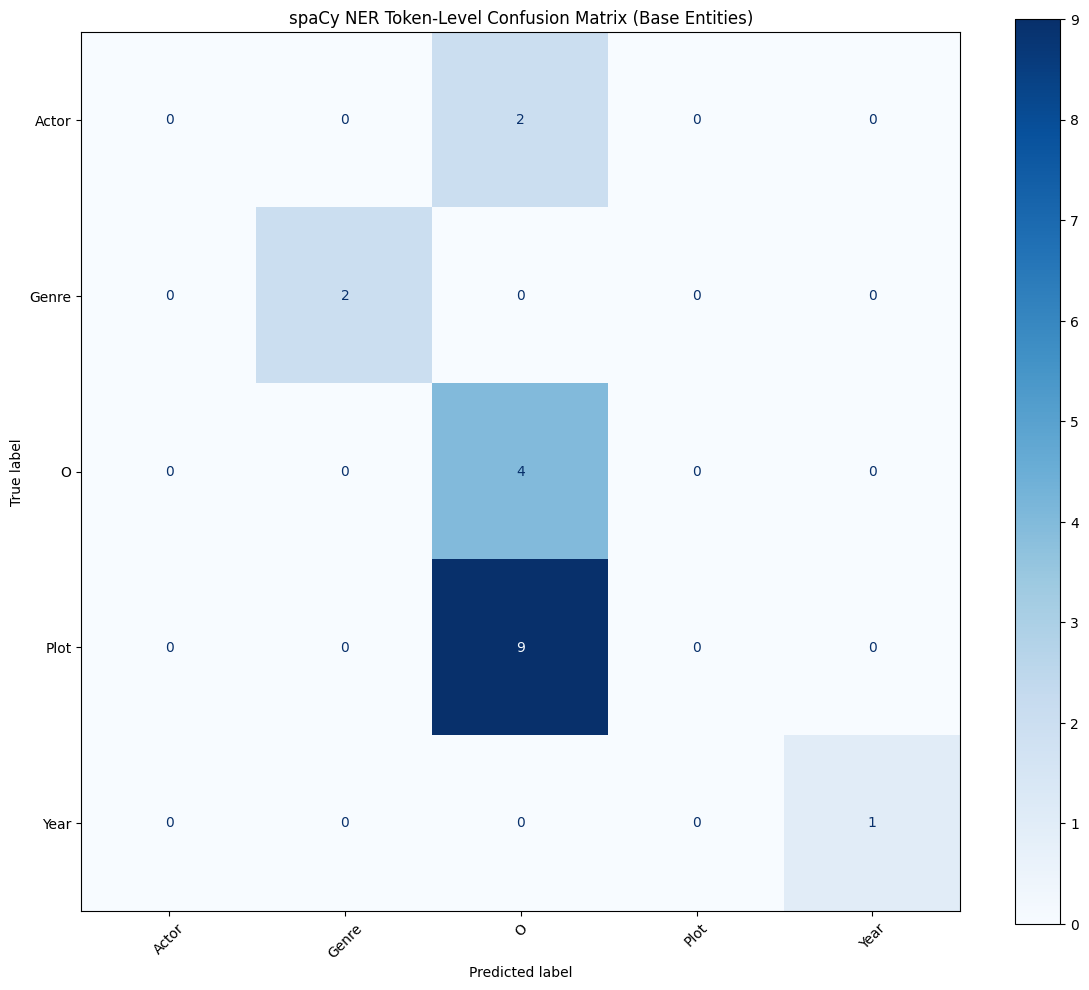

In [118]:
# Use the ner_examples list generated from the single test case
calculate_ner_confusion_matrix(ner_examples)

# Experiment Setup: Creating the Experiment Dataset

First, we will randomly select 100 examples from the `test` split of the `tner/mit_movie_trivia` dataset. These will serve as our test samples for the experimentation.

In [94]:
# Randomly select 100 examples from the test dataset
import random

num_test_samples = 100

# Get random indices for the test set
random_test_indices = random.sample(range(len(dataset['test'])), num_test_samples)

# Create a list of AnnotatedDocument objects for the selected test samples
experiment_test_data = []
for idx in random_test_indices:
    test_example = dataset['test'][idx]
    annotated_doc = create_annotated_document_from_tokens_and_tags(
        test_example['tokens'], test_example['tags'], reverse_tag_mapper
    )
    experiment_test_data.append(annotated_doc)

print(f"Created {len(experiment_test_data)} annotated documents for the experiment test set.")

# Display the first selected test document
print("\nFirst selected experiment test document:")
print(experiment_test_data[0].text)
print(experiment_test_data[0].annotations)

Created 100 annotated documents for the experiment test set.

First selected experiment test document:
name the 1993 movie epic based in world war 2 about the nazis
[Annotation(start=20, end=24, label='Opinion', text=None), Annotation(start=34, end=61, label='Plot', text=None), Annotation(start=9, end=13, label='Year', text=None)]


Next, for each test example, we need to find relevant training examples. A training example is considered relevant if it contains *all* entity types present in the current test example. We will limit the number of such training examples to 20 per test example.

In [95]:
# Pre-process the training dataset to extract AnnotatedDocument and their entity labels
print("Preprocessing training data...")
processed_training_data = []
for i, train_example in enumerate(dataset['train']):
    train_doc = create_annotated_document_from_tokens_and_tags(
        train_example['tokens'], train_example['tags'], reverse_tag_mapper
    )
    # Extract unique entity labels from the training document
    train_entity_labels = {ann.label for ann in train_doc.annotations}
    processed_training_data.append({
        'annotated_doc': train_doc,
        'entity_labels': train_entity_labels
    })
print(f"Finished preprocessing {len(processed_training_data)} training examples.")

# Create the final experiment dataset with matching training examples
experiment_dataset = []
MAX_FEW_SHOT_EXAMPLES = 20 # Limit to 20 few-shot examples per test sample

print("\nMatching training examples for each test sample...")
for i, test_doc in enumerate(experiment_test_data):
    test_entity_labels = {ann.label for ann in test_doc.annotations}
    matched_few_shot_examples = []

    # Iterate through pre-processed training data to find matches
    for train_item in processed_training_data:
        train_doc = train_item['annotated_doc']
        train_entity_labels = train_item['entity_labels']

        # Condition: All entities in the test object must be present in the training sample
        if test_entity_labels.issubset(train_entity_labels):
            matched_few_shot_examples.append(train_doc)
            if len(matched_few_shot_examples) >= MAX_FEW_SHOT_EXAMPLES:
                break # Stop if we found enough examples

    experiment_dataset.append({
        'test_document': test_doc,
        'few_shot_examples': matched_few_shot_examples
    })
    print(f"Test sample {i+1}/{len(experiment_test_data)} has {len(matched_few_shot_examples)} matching training examples.")

print("\nExperiment dataset creation complete.")
print(f"Total items in experiment dataset: {len(experiment_dataset)}")
print("\nExample of an experiment dataset entry (first item):")
print(f"Test document text: {experiment_dataset[0]['test_document'].text}")
print(f"Test document annotations: {experiment_dataset[0]['test_document'].annotations}")
print(f"Number of few-shot examples for this test document: {len(experiment_dataset[0]['few_shot_examples'])}")
if experiment_dataset[0]['few_shot_examples']:
    print(f"First few-shot example text: {experiment_dataset[0]['few_shot_examples'][0].text}")
    print(f"First few-shot example annotations: {experiment_dataset[0]['few_shot_examples'][0].annotations}")

Preprocessing training data...
Finished preprocessing 6816 training examples.

Matching training examples for each test sample...
Test sample 1/100 has 20 matching training examples.
Test sample 2/100 has 20 matching training examples.
Test sample 3/100 has 20 matching training examples.
Test sample 4/100 has 15 matching training examples.
Test sample 5/100 has 20 matching training examples.
Test sample 6/100 has 20 matching training examples.
Test sample 7/100 has 20 matching training examples.
Test sample 8/100 has 20 matching training examples.
Test sample 9/100 has 20 matching training examples.
Test sample 10/100 has 20 matching training examples.
Test sample 11/100 has 20 matching training examples.
Test sample 12/100 has 20 matching training examples.
Test sample 13/100 has 20 matching training examples.
Test sample 14/100 has 20 matching training examples.
Test sample 15/100 has 3 matching training examples.
Test sample 16/100 has 20 matching training examples.
Test sample 17/1

In [113]:
dataset_path = '/content/gdrive/MyDrive/msds_466_genai/final/experiment_dataset.pkl'

# Ensure the directory exists (optional but good practice if not already created)
os.makedirs(os.path.dirname(dataset_path), exist_ok=True)

with open(dataset_path, 'wb') as f:
    pickle.dump(experiment_dataset, f)

print(f"Experiment dataset saved to {dataset_path}")

Experiment dataset saved to /content/gdrive/MyDrive/msds_466_genai/final/experiment_dataset.pkl


# Experiment 1: Zero-Shot NER Evaluation

Here we will run all 100 test samples through the Zero-Shot NER model. To save on API costs and time in case the kernel disconnects, we will use Python's `pickle` library to save the exact object structures returned by the model.

In [ ]:
dataset_path = '/content/gdrive/MyDrive/msds_466_genai/final/experiment_dataset.pkl'

# Check if experiment_dataset is initialized; if not, load from pickle
if 'experiment_dataset' not in locals() and 'experiment_dataset' not in globals():
    if os.path.exists(dataset_path):
        print("Loading experiment_dataset from pickle...")
        with open(dataset_path, 'rb') as f:
            experiment_dataset = pickle.load(f)
        print("Successfully loaded experiment_dataset!")
    else:
        raise FileNotFoundError(f"experiment_dataset is not initialized and pickle file not found at {dataset_path}")

# Define a path in your mounted Google Drive to save the predictions
zero_shot_results_path = '/content/gdrive/MyDrive/msds_466_genai/final/zero_shot_predictions.pkl'

# Prepare the inputs
texts_to_predict = [item['test_document'].text for item in experiment_dataset]
ground_truth_docs = [item['test_document'] for item in experiment_dataset]

# Check if we already have saved predictions
if os.path.exists(zero_shot_results_path):
    print("Found existing Zero-Shot predictions. Loading from pickle...")
    with open(zero_shot_results_path, 'rb') as f:
        zero_shot_predictions = pickle.load(f)
    print("Loaded successfully!")
else:
    print("No saved predictions found. Running Zero-Shot NER via OpenAI API (this may take a few minutes)...")

    # Run prediction for all 100 items
    # Note: model.predict() accepts a list of strings
    # zero_shot_predictions = model.predict(texts_to_predict)

    # Save the output to pickle so we don't have to re-run it
    with open(zero_shot_results_path, 'wb') as f:
        pickle.dump(zero_shot_predictions, f)
    print(f"Predictions saved to {zero_shot_results_path}!")

In [115]:
print("--- Zero-Shot Predictions Sanity Check (First 5 Samples) ---\n")

for i in range(min(5, len(zero_shot_predictions))):
    prediction = zero_shot_predictions[i]
    print(f"Sample {i+1}:")
    if hasattr(prediction, 'text'):
        print(f"  Text: '{prediction.text}'")
        print(f"  Annotations: {prediction.annotations}")
    else:
        print(f"  Raw Output: {prediction}")

    # Check if there were any alignment exceptions reported by llmner
    if hasattr(prediction, 'exception') and prediction.exception is not None:
        print(f"  Exception: {prediction.exception}")
    print("-" * 60)

--- Zero-Shot Predictions Sanity Check (First 5 Samples) ---

Sample 1:
  Text: 'name the 1993 movie epic based in world war 2 about the nazis'
  Annotations: {Annotation(start=34, end=61, label='Plot', text='world war 2 about the nazis'), Annotation(start=9, end=13, label='Year', text='1993')}
------------------------------------------------------------
Sample 2:
  Text: 'arnold the governator schwarzenegger s 1982 classic follows the adventures of the eponymous character in a world of dark magic and savagery'
  Annotations: {Annotation(start=0, end=36, label='Actor', text='arnold the governator schwarzenegger'), Annotation(start=39, end=43, label='Year', text='1982'), Annotation(start=92, end=101, label='Character_Name', text='character')}
------------------------------------------------------------
Sample 3:
  Text: 'what was the movie with mark wahlberg that came out around 2001 with the primates along with humans'
  Annotations: {Annotation(start=59, end=63, label='Year', text='20

### Evaluate Zero-Shot Predictions

Now we will pass the ground truth and predicted documents into our evaluation functions.

Preparing examples for evaluation...

   ZERO-SHOT ENTITY-LEVEL EVALUATION   

--- NER Evaluation Results ---
Precision: 0.58
Recall: 0.42
F1 Score: 0.49

    ZERO-SHOT TOKEN-LEVEL EVALUATION   

--- NER Token-Level Confusion Matrix Results ---
Labels (Base Entity Types): ['Actor', 'Award', 'Character_Name', 'Director', 'Genre', 'O', 'Opinion', 'Origin', 'Plot', 'Quote', 'Relationship', 'Year']
Confusion Matrix:
 [[ 74   0   0   0   0  73   0   0   0   0   0   0]
 [  0   6   0   0   0   2   0   0   0   0   0   0]
 [  0   0  22   0   0  11   0   0   0   2   0   0]
 [  5   0   0  24   0   8   0   1   0   0   0   0]
 [  0   0   0   0  51  10   0   2   2   0   0   0]
 [  0   1   1   0   6 744   0   3   8   0   0   1]
 [  0   0   0   0   1   7   0   0   0   0   0   0]
 [ 10   0   0   0   0  45   0   2   5   0   0   0]
 [  1   0  35   0   4 574   0  11  81   0   7   7]
 [  0   0   0   0   0  13   0   0   0  20   0   0]
 [  0   0   0   0   2  10   0   0   0   0   0   2]
 [  0   0   0   0   0 

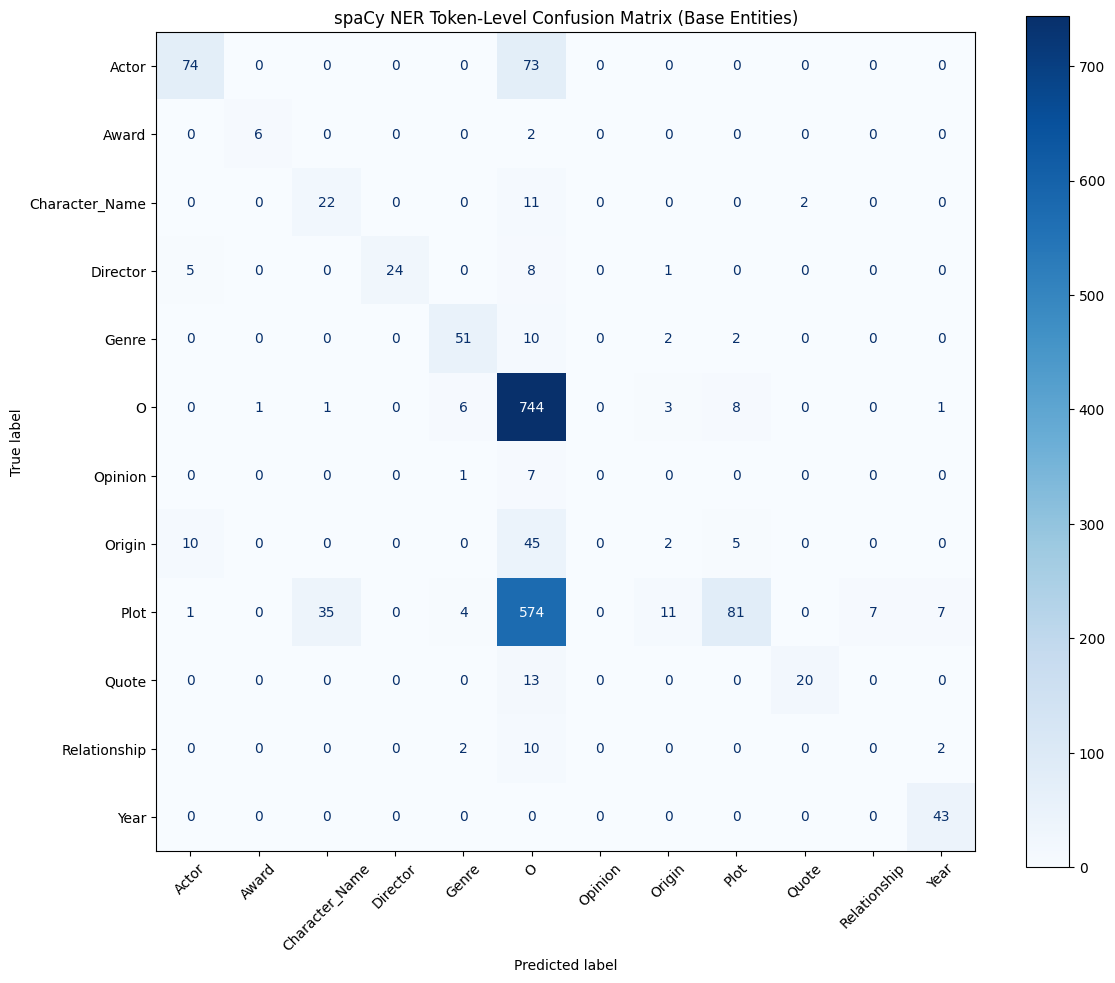

In [119]:
# 1. Create the Example objects for spaCy
print("Preparing examples for evaluation...")
zero_shot_examples = create_ner_examples_for_spacy_scorer(
    ground_truth_docs=ground_truth_docs,
    predicted_docs=zero_shot_predictions
)

# 2. Entity-Level Evaluation (Scorer)
print("\n=========================================")
print("   ZERO-SHOT ENTITY-LEVEL EVALUATION   ")
print("=========================================")
zero_shot_evaluation_scores = score_ner_examples(examples=zero_shot_examples)

# 3. Token-Level Evaluation (Confusion Matrix)
print("\n=========================================")
print("    ZERO-SHOT TOKEN-LEVEL EVALUATION   ")
print("=========================================")
calculate_ner_confusion_matrix(examples=zero_shot_examples)

# Experiment 2: One-Shot NER Evaluation

In this experiment, we use the `FewShotNer` class. For each test document, we provide exactly **one** matching training example (which contains all the entity types present in the test document) to guide the LLM.

In [ ]:
from llmner import FewShotNer
import os
import pickle

# Define path for one-shot predictions
one_shot_results_path = '/content/gdrive/MyDrive/msds_466_genai/final/one_shot_predictions.pkl'

if os.path.exists(one_shot_results_path):
    print("Found existing One-Shot predictions. Loading from pickle...")
    with open(one_shot_results_path, 'rb') as f:
        one_shot_predictions = pickle.load(f)
    print("Loaded successfully!")
else:
    print("No saved predictions found. Running One-Shot NER via OpenAI API (this may take a few minutes)...")
    one_shot_predictions = []

    for i, item in enumerate(experiment_dataset):
        test_text = item['test_document'].text

        # Take exactly 1 matching few-shot example for "One-Shot"
        # If no matches were found during dataset creation, it will pass an empty list (effectively zero-shot fallback)
        one_shot_example = item['few_shot_examples'][:1]

        # Initialize the FewShotNer model
        model = FewShotNer(model="gpt-4.1-mini")

        # Contextualize with the entity descriptions and the single example
        model.contextualize(entities=entities_descriptions, examples=one_shot_example)

        # Predict for the single test text (predict expects a list of strings)
        # prediction = model.predict([test_text])[0]
        one_shot_predictions.append(prediction)

        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{len(experiment_dataset)} samples...")

    # Save the output to pickle
    with open(one_shot_results_path, 'wb') as f:
        pickle.dump(one_shot_predictions, f)
    print(f"Predictions saved to {one_shot_results_path}!")

In [123]:
print("--- One-Shot Predictions Sanity Check (First 5 Samples) ---\n")

for i in range(min(5, len(one_shot_predictions))):
    prediction = one_shot_predictions[i]
    print(f"Sample {i+1}:")
    if hasattr(prediction, 'text'):
        print(f"  Text: '{prediction.text}'")
        print(f"  Annotations: {prediction.annotations}")
    else:
        print(f"  Raw Output: {prediction}")

    if hasattr(prediction, 'exception') and prediction.exception is not None:
        print(f"  Exception: {prediction.exception}")
    print("-" * 60)

--- One-Shot Predictions Sanity Check (First 5 Samples) ---

Sample 1:
  Text: 'name the 1993 movie epic based in world war 2 about the nazis'
  Annotations: {Annotation(start=56, end=61, label='Plot', text='nazis'), Annotation(start=20, end=24, label='Genre', text='epic'), Annotation(start=34, end=45, label='Plot', text='world war 2'), Annotation(start=9, end=13, label='Year', text='1993')}
------------------------------------------------------------
Sample 2:
  Text: 'arnold the governator schwarzenegger s 1982 classic follows the adventures of the eponymous character in a world of dark magic and savagery'
  Annotations: {Annotation(start=0, end=36, label='Actor', text='arnold the governator schwarzenegger'), Annotation(start=39, end=43, label='Year', text='1982'), Annotation(start=92, end=101, label='Character_Name', text='character')}
------------------------------------------------------------
Sample 3:
  Text: 'what was the movie with mark wahlberg that came out around 2001 with 

Preparing examples for One-Shot evaluation...

    ONE-SHOT ENTITY-LEVEL EVALUATION   

--- NER Evaluation Results ---
Precision: 0.61
Recall: 0.64
F1 Score: 0.63

     ONE-SHOT TOKEN-LEVEL EVALUATION   

--- NER Token-Level Confusion Matrix Results ---
Labels (Base Entity Types): ['Actor', 'Award', 'Character_Name', 'Director', 'Genre', 'O', 'Opinion', 'Origin', 'Plot', 'Quote', 'Relationship', 'Soundtrack', 'Year']
Confusion Matrix:
 [[144   0   0   0   0   2   0   0   0   0   1   0   0]
 [  0   7   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0  30   0   0   3   0   0   0   2   0   0   0]
 [  7   0   0  30   0   0   0   1   0   0   0   0   0]
 [  0   0   0   0  55   5   0   4   1   0   0   0   0]
 [  1   1   5   2   4 726   0   4  18   0   2   0   1]
 [  0   0   0   0   1   3   4   0   0   0   0   0   0]
 [  5   0   0   0   0  35   0  15   5   0   0   0   2]
 [  0   0  50   0   6 292   8  13 334   0   9   4   4]
 [  0   0   0   0   0   0   0   0   0  33   0   0   0]
 [  0   0 

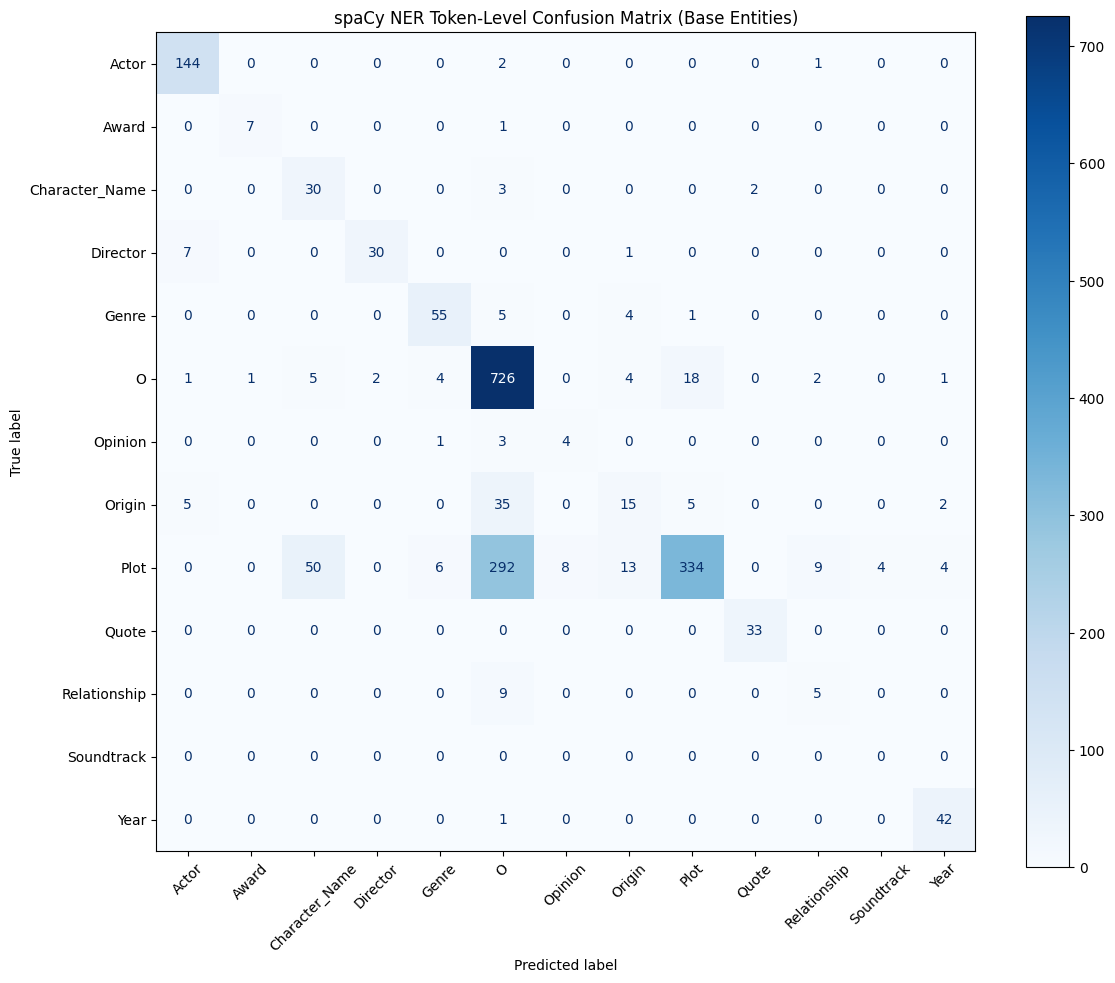

In [124]:
# 1. Create the Example objects for spaCy
print("Preparing examples for One-Shot evaluation...")
one_shot_examples = create_ner_examples_for_spacy_scorer(
    ground_truth_docs=ground_truth_docs,
    predicted_docs=one_shot_predictions
)

# 2. Entity-Level Evaluation (Scorer)
print("\n=========================================")
print("    ONE-SHOT ENTITY-LEVEL EVALUATION   ")
print("=========================================")
one_shot_evaluation_scores = score_ner_examples(examples=one_shot_examples)

# 3. Token-Level Evaluation (Confusion Matrix)
print("\n=========================================")
print("     ONE-SHOT TOKEN-LEVEL EVALUATION   ")
print("=========================================")
calculate_ner_confusion_matrix(examples=one_shot_examples)

# Experiment 3: Few-Shot NER Evaluation (n=5)

In this experiment, we provide up to **5** matching training examples to the `FewShotNer` model.

**Handling Missing Samples:** Some test samples have fewer than 5 matching training examples. We decided to use however many are available (up to 5) instead of other alternatives:
* **Duplicating samples:** This was avoided because duplicating the same example provides no new linguistic patterns for the model to learn from, and it often leads to the model hallucinating or overfitting on that specific text.
* **Limiting to the global minimum:** The minimum number of matching examples across our dataset is 0. If we limited all tests to the global minimum to ensure an equal number of shots, we would effectively revert to a Zero-Shot experiment, defeating the purpose.

In [ ]:
# Define path for few-shot predictions
few_shot_results_path = '/content/gdrive/MyDrive/msds_466_genai/final/few_shot_predictions.pkl'

if os.path.exists(few_shot_results_path):
    print("Found existing Few-Shot predictions. Loading from pickle...")
    with open(few_shot_results_path, 'rb') as f:
        few_shot_predictions = pickle.load(f)
    print("Loaded successfully!")
else:
    print("No saved predictions found. Running Few-Shot NER via OpenAI API (this may take a few minutes)...")
    few_shot_predictions = []

    for i, item in enumerate(experiment_dataset):
        test_text = item['test_document'].text

        # Take up to 5 matching few-shot examples
        few_shot_example_list = item['few_shot_examples'][:5]

        # Initialize the FewShotNer model
        model = FewShotNer(model="gpt-4.1-mini")

        # Contextualize with the entity descriptions and the examples
        model.contextualize(entities=entities_descriptions, examples=few_shot_example_list)

        # Predict for the single test text
        # prediction = model.predict([test_text])[0]
        few_shot_predictions.append(prediction)

        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{len(experiment_dataset)} samples...")

    # Save the output to pickle
    with open(few_shot_results_path, 'wb') as f:
        pickle.dump(few_shot_predictions, f)
    print(f"Predictions saved to {few_shot_results_path}!")

In [127]:
print("--- Few-Shot Predictions Sanity Check (First 5 Samples) ---\n")

for i in range(min(5, len(few_shot_predictions))):
    prediction = few_shot_predictions[i]
    print(f"Sample {i+1}:")
    if hasattr(prediction, 'text'):
        print(f"  Text: '{prediction.text}'")
        print(f"  Annotations: {prediction.annotations}")
    else:
        print(f"  Raw Output: {prediction}")

    if hasattr(prediction, 'exception') and prediction.exception is not None:
        print(f"  Exception: {prediction.exception}")
    print("-" * 60)

--- Few-Shot Predictions Sanity Check (First 5 Samples) ---

Sample 1:
  Text: 'name the 1993 movie epic based in world war 2 about the nazis'
  Annotations: {Annotation(start=20, end=24, label='Genre', text='epic'), Annotation(start=34, end=61, label='Plot', text='world war 2 about the nazis'), Annotation(start=9, end=13, label='Year', text='1993')}
------------------------------------------------------------
Sample 2:
  Text: 'arnold the governator schwarzenegger s 1982 classic follows the adventures of the eponymous character in a world of dark magic and savagery'
  Annotations: {Annotation(start=0, end=36, label='Actor', text='arnold the governator schwarzenegger'), Annotation(start=82, end=101, label='Character_Name', text='eponymous character'), Annotation(start=116, end=139, label='Plot', text='dark magic and savagery'), Annotation(start=39, end=43, label='Year', text='1982')}
------------------------------------------------------------
Sample 3:
  Text: 'what was the movie with

Preparing examples for Few-Shot evaluation...

    FEW-SHOT ENTITY-LEVEL EVALUATION   

--- NER Evaluation Results ---
Precision: 0.60
Recall: 0.64
F1 Score: 0.62

     FEW-SHOT TOKEN-LEVEL EVALUATION   

--- NER Token-Level Confusion Matrix Results ---
Labels (Base Entity Types): ['Actor', 'Award', 'Character_Name', 'Director', 'Genre', 'O', 'Opinion', 'Origin', 'Plot', 'Quote', 'Relationship', 'Year']
Confusion Matrix:
 [[143   0   0   0   0   4   0   0   0   0   0   0]
 [  0   7   0   0   0   1   0   0   0   0   0   0]
 [  3   0  27   0   0   3   0   0   0   2   0   0]
 [  7   0   0  28   0   2   0   1   0   0   0   0]
 [  0   0   0   0  57   3   0   3   1   0   1   0]
 [  1   1   9   0   4 711   1   7  15   0  11   4]
 [  0   0   0   0   1   1   6   0   0   0   0   0]
 [  3   0   0   0   0  24   0  28   5   0   0   2]
 [  0   0  37   0   4 222   3  17 428   0   8   1]
 [  0   0   0   0   0   0   0   0   0  33   0   0]
 [  0   0   0   0   0   1   0   0   0   0  11   2]
 [  0   0   0

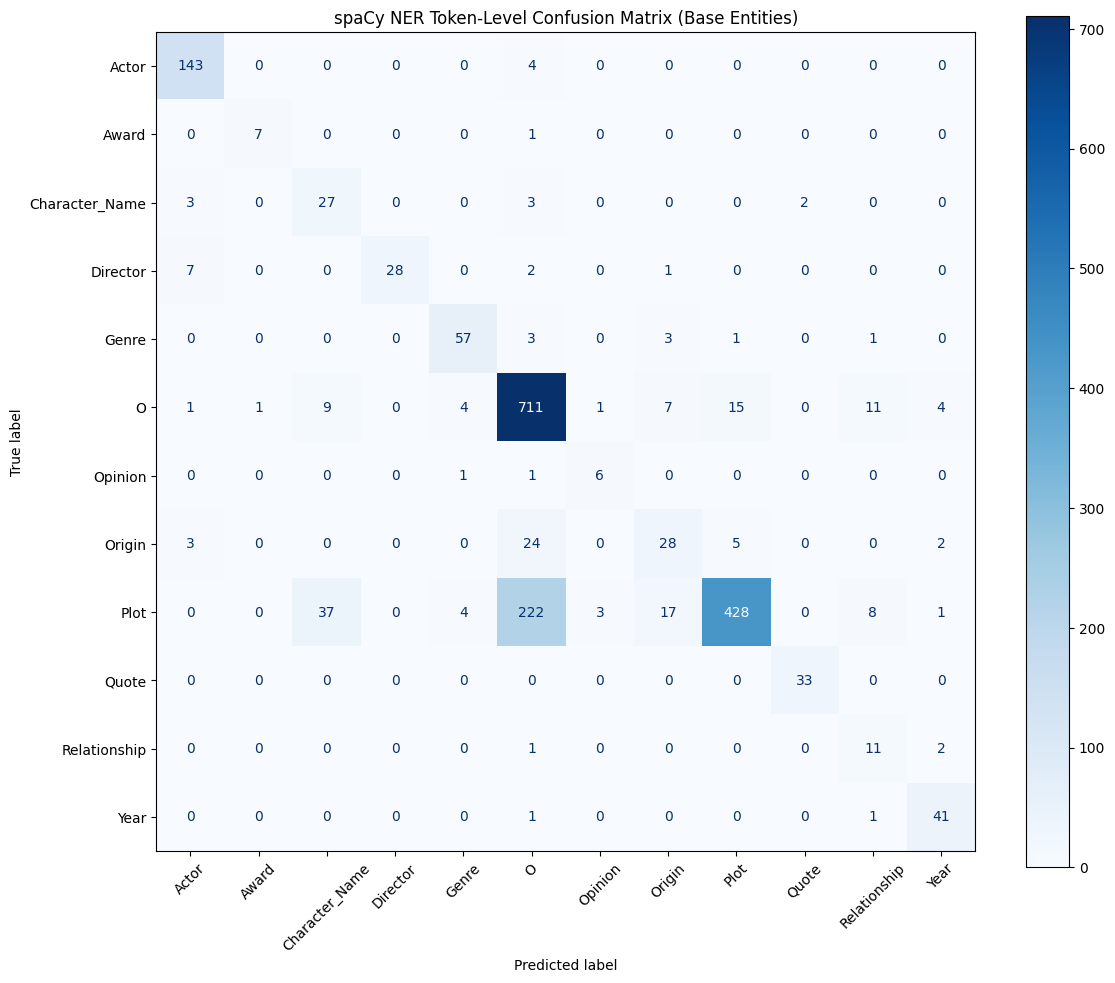

In [131]:
# 1. Create the Example objects for spaCy
print("Preparing examples for Few-Shot evaluation...")
few_shot_examples = create_ner_examples_for_spacy_scorer(
    ground_truth_docs=ground_truth_docs,
    predicted_docs=few_shot_predictions
)

# 2. Entity-Level Evaluation (Scorer)
print("\n=========================================")
print("    FEW-SHOT ENTITY-LEVEL EVALUATION   ")
print("=========================================")
few_shot_evaluation_scores = score_ner_examples(examples=few_shot_examples)

# 3. Token-Level Evaluation (Confusion Matrix)
print("\n=========================================")
print("     FEW-SHOT TOKEN-LEVEL EVALUATION   ")
print("=========================================")
calculate_ner_confusion_matrix(examples=few_shot_examples)

# Experiment 4: Few-Shot NER Evaluation (n=10)

In this experiment, we provide up to **10** matching training examples to the `FewShotNer` model. Similar to the previous experiment, if fewer than 10 examples are available, we will pass all available matching examples.

In [ ]:
few_shot_10_results_path = '/content/gdrive/MyDrive/msds_466_genai/final/few_shot_10_predictions.pkl'

if os.path.exists(few_shot_10_results_path):
    print("Found existing Few-Shot (n=10) predictions. Loading from pickle...")
    with open(few_shot_10_results_path, 'rb') as f:
        few_shot_10_predictions = pickle.load(f)
    print("Loaded successfully!")
else:
    print("No saved predictions found. Running Few-Shot (n=10) NER via OpenAI API (this may take a few minutes)...")
    few_shot_10_predictions = []

    for i, item in enumerate(experiment_dataset):
        test_text = item['test_document'].text

        # Take up to 10 matching few-shot examples
        few_shot_10_example_list = item['few_shot_examples'][:10]

        # Initialize the FewShotNer model
        model = FewShotNer(model="gpt-4.1-mini")

        # Contextualize with the entity descriptions and the examples
        model.contextualize(entities=entities_descriptions, examples=few_shot_10_example_list)

        # Predict for the single test text
        # prediction = model.predict([test_text])[0]
        few_shot_10_predictions.append(prediction)

        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{len(experiment_dataset)} samples...")

    # Save the output to pickle
    with open(few_shot_10_results_path, 'wb') as f:
        pickle.dump(few_shot_10_predictions, f)
    print(f"Predictions saved to {few_shot_10_results_path}!")

In [133]:
print("--- Few-Shot (n=10) Predictions Sanity Check (First 5 Samples) ---\n")

for i in range(min(5, len(few_shot_10_predictions))):
    prediction = few_shot_10_predictions[i]
    print(f"Sample {i+1}:")
    if hasattr(prediction, 'text'):
        print(f"  Text: '{prediction.text}'")
        print(f"  Annotations: {prediction.annotations}")
    else:
        print(f"  Raw Output: {prediction}")

    if hasattr(prediction, 'exception') and prediction.exception is not None:
        print(f"  Exception: {prediction.exception}")
    print("-" * 60)

--- Few-Shot (n=10) Predictions Sanity Check (First 5 Samples) ---

Sample 1:
  Text: 'name the 1993 movie epic based in world war 2 about the nazis'
  Annotations: {Annotation(start=34, end=61, label='Plot', text='world war 2 about the nazis'), Annotation(start=9, end=13, label='Year', text='1993')}
------------------------------------------------------------
Sample 2:
  Text: 'arnold the governator schwarzenegger s 1982 classic follows the adventures of the eponymous character in a world of dark magic and savagery'
  Annotations: {Annotation(start=0, end=36, label='Actor', text='arnold the governator schwarzenegger'), Annotation(start=82, end=101, label='Character_Name', text='eponymous character'), Annotation(start=107, end=139, label='Plot', text='world of dark magic and savagery'), Annotation(start=39, end=43, label='Year', text='1982')}
------------------------------------------------------------
Sample 3:
  Text: 'what was the movie with mark wahlberg that came out around 2001 w

Preparing examples for Few-Shot (n=10) evaluation...

  FEW-SHOT (n=10) ENTITY-LEVEL EVALUATION  

--- NER Evaluation Results ---
Precision: 0.66
Recall: 0.69
F1 Score: 0.68

   FEW-SHOT (n=10) TOKEN-LEVEL EVALUATION  

--- NER Token-Level Confusion Matrix Results ---
Labels (Base Entity Types): ['Actor', 'Award', 'Character_Name', 'Director', 'Genre', 'O', 'Opinion', 'Origin', 'Plot', 'Quote', 'Relationship', 'Year']
Confusion Matrix:
 [[141   0   0   0   0   6   0   0   0   0   0   0]
 [  0   7   0   0   0   1   0   0   0   0   0   0]
 [  0   0  30   0   0   3   0   0   0   2   0   0]
 [  5   0   0  32   1   0   0   0   0   0   0   0]
 [  0   0   0   0  58   1   0   4   1   0   1   0]
 [  0   1  14   0   4 700   1  13  21   0   9   1]
 [  0   0   0   0   0   2   6   0   0   0   0   0]
 [  3   0   0   0   0  21   0  26  10   0   0   2]
 [  0   0  24   0  15 172   2  11 491   0   4   1]
 [  0   0   0   0   0   0   0   0   0  33   0   0]
 [  0   0   0   0   0   1   0   0   0   0  11   2

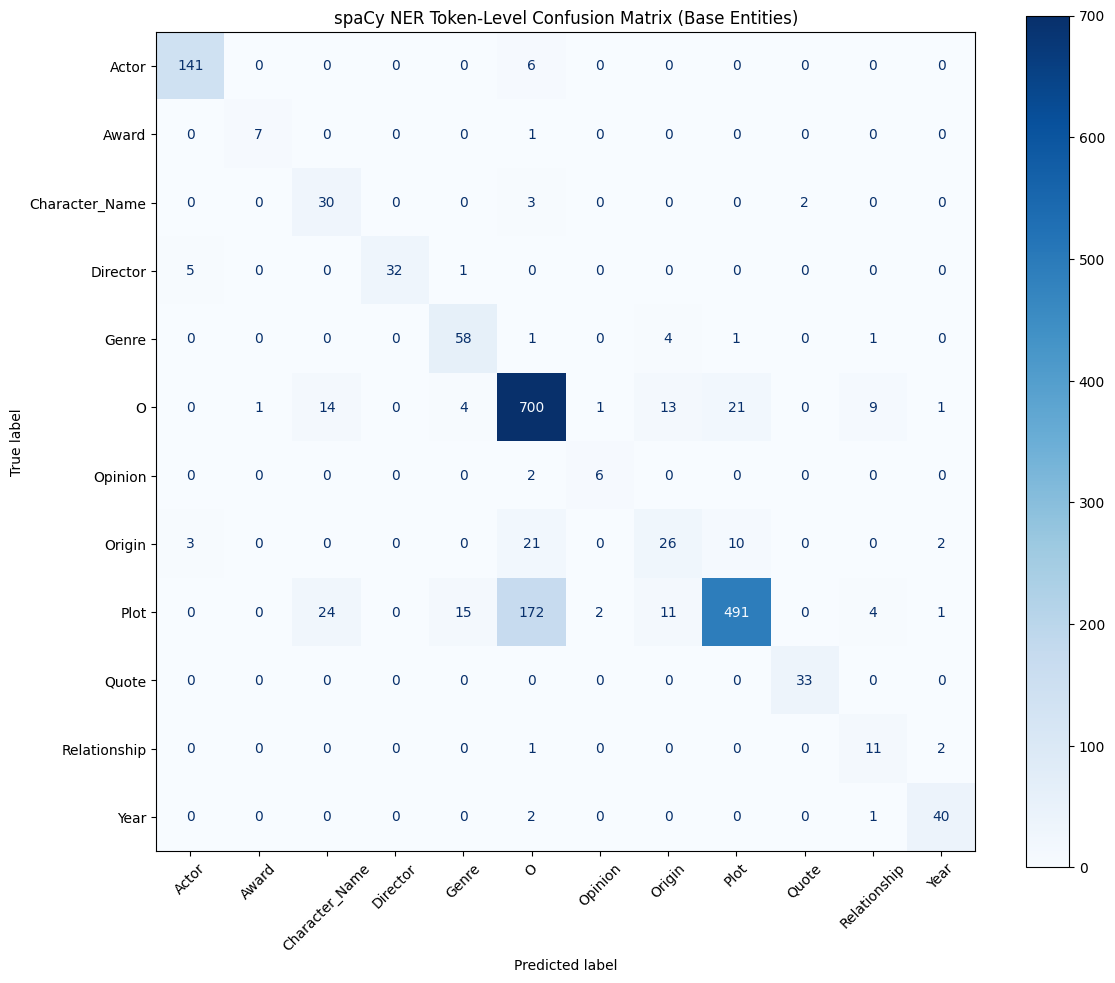

In [134]:
# 1. Create the Example objects for spaCy
print("Preparing examples for Few-Shot (n=10) evaluation...")
few_shot_10_examples = create_ner_examples_for_spacy_scorer(
    ground_truth_docs=ground_truth_docs,
    predicted_docs=few_shot_10_predictions
)

# 2. Entity-Level Evaluation (Scorer)
print("\n=========================================")
print("  FEW-SHOT (n=10) ENTITY-LEVEL EVALUATION  ")
print("=========================================")
few_shot_10_evaluation_scores = score_ner_examples(examples=few_shot_10_examples)

# 3. Token-Level Evaluation (Confusion Matrix)
print("\n=========================================")
print("   FEW-SHOT (n=10) TOKEN-LEVEL EVALUATION  ")
print("=========================================")
calculate_ner_confusion_matrix(examples=few_shot_10_examples)

# Experiment 5: Few-Shot NER Evaluation (n=20)

In this experiment, we provide up to **20** matching training examples to the `FewShotNer` model. Similar to the previous experiments, if fewer than 20 examples are available, we will pass all available matching examples.

In [ ]:
few_shot_20_results_path = '/content/gdrive/MyDrive/msds_466_genai/final/few_shot_20_predictions.pkl'

if os.path.exists(few_shot_20_results_path):
    print("Found existing Few-Shot (n=20) predictions. Loading from pickle...")
    with open(few_shot_20_results_path, 'rb') as f:
        few_shot_20_predictions = pickle.load(f)
    print("Loaded successfully!")
else:
    print("No saved predictions found. Running Few-Shot (n=20) NER via OpenAI API (this may take a few minutes)...")
    few_shot_20_predictions = []

    for i, item in enumerate(experiment_dataset):
        test_text = item['test_document'].text

        # Take up to 20 matching few-shot examples
        few_shot_20_example_list = item['few_shot_examples'][:20]

        # Initialize the FewShotNer model
        model = FewShotNer(model="gpt-4.1-mini")

        # Contextualize with the entity descriptions and the examples
        model.contextualize(entities=entities_descriptions, examples=few_shot_20_example_list)

        # Predict for the single test text
        # prediction = model.predict([test_text])[0]
        few_shot_20_predictions.append(prediction)

        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{len(experiment_dataset)} samples...")

    # Save the output to pickle
    with open(few_shot_20_results_path, 'wb') as f:
        pickle.dump(few_shot_20_predictions, f)
    print(f"Predictions saved to {few_shot_20_results_path}!")

In [141]:
print("--- Few-Shot (n=20) Predictions Sanity Check (First 5 Samples) ---\n")

for i in range(min(5, len(few_shot_20_predictions))):
    prediction = few_shot_20_predictions[i]
    print(f"Sample {i+1}:")
    if hasattr(prediction, 'text'):
        print(f"  Text: '{prediction.text}'")
        print(f"  Annotations: {prediction.annotations}")
    else:
        print(f"  Raw Output: {prediction}")

    if hasattr(prediction, 'exception') and prediction.exception is not None:
        print(f"  Exception: {prediction.exception}")
    print("-" * 60)

--- Few-Shot (n=20) Predictions Sanity Check (First 5 Samples) ---

Sample 1:
  Text: 'name the 1993 movie epic based in world war 2 about the nazis'
  Annotations: {Annotation(start=20, end=24, label='Opinion', text='epic'), Annotation(start=25, end=61, label='Plot', text='based in world war 2 about the nazis'), Annotation(start=9, end=13, label='Year', text='1993')}
------------------------------------------------------------
Sample 2:
  Text: 'arnold the governator schwarzenegger s 1982 classic follows the adventures of the eponymous character in a world of dark magic and savagery'
  Annotations: {Annotation(start=44, end=51, label='Opinion', text='classic'), Annotation(start=107, end=139, label='Plot', text='world of dark magic and savagery'), Annotation(start=0, end=36, label='Actor', text='arnold the governator schwarzenegger'), Annotation(start=39, end=43, label='Year', text='1982'), Annotation(start=92, end=101, label='Character_Name', text='character')}
-----------------------

Preparing examples for Few-Shot (n=20) evaluation...

  FEW-SHOT (n=20) ENTITY-LEVEL EVALUATION  

--- NER Evaluation Results ---
Precision: 0.66
Recall: 0.68
F1 Score: 0.67

   FEW-SHOT (n=20) TOKEN-LEVEL EVALUATION  

--- NER Token-Level Confusion Matrix Results ---
Labels (Base Entity Types): ['Actor', 'Award', 'Character_Name', 'Director', 'Genre', 'O', 'Opinion', 'Origin', 'Plot', 'Quote', 'Relationship', 'Year']
Confusion Matrix:
 [[142   0   0   0   0   4   0   0   0   0   1   0]
 [  0   7   0   0   0   1   0   0   0   0   0   0]
 [  0   0  32   0   0   1   0   0   0   2   0   0]
 [  5   0   0  32   1   0   0   0   0   0   0   0]
 [  0   0   0   0  57   3   0   4   0   0   1   0]
 [  0   1   3   0   6 695   3  11  33   0  11   1]
 [  0   0   0   0   0   1   7   0   0   0   0   0]
 [  3   0   0   0   0  20   0  37   0   0   0   2]
 [  0   0  16   0   0 133   7  12 544   0   8   0]
 [  0   0   0   0   0   6   0   0   0  27   0   0]
 [  0   0   0   0   0   1   0   0   0   0  11   2

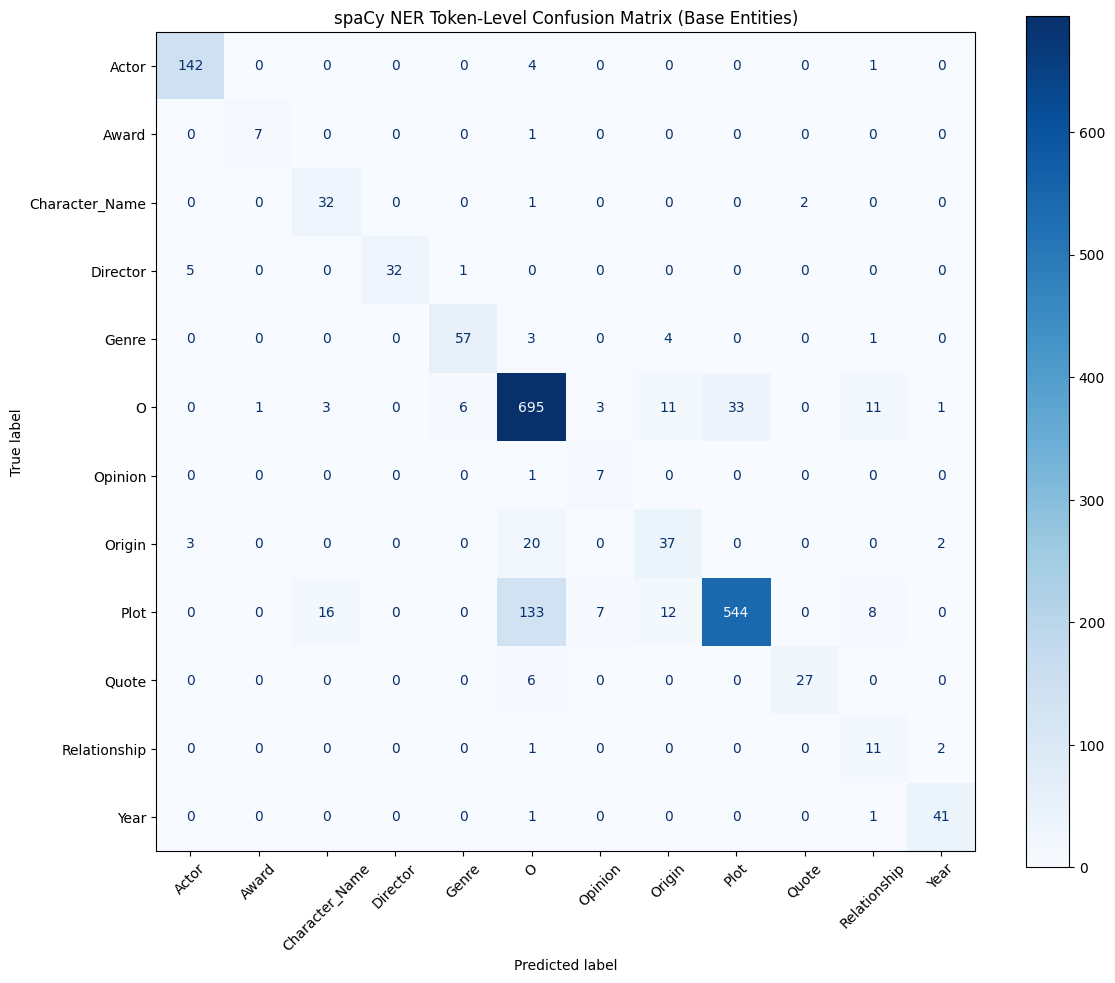

In [142]:
# 1. Create the Example objects for spaCy
print("Preparing examples for Few-Shot (n=20) evaluation...")
few_shot_20_examples = create_ner_examples_for_spacy_scorer(
    ground_truth_docs=ground_truth_docs,
    predicted_docs=few_shot_20_predictions
)

# 2. Entity-Level Evaluation (Scorer)
print("\n=========================================")
print("  FEW-SHOT (n=20) ENTITY-LEVEL EVALUATION  ")
print("=========================================")
few_shot_20_evaluation_scores = score_ner_examples(examples=few_shot_20_examples)

# 3. Token-Level Evaluation (Confusion Matrix)
print("\n=========================================")
print("   FEW-SHOT (n=20) TOKEN-LEVEL EVALUATION  ")
print("=========================================")
calculate_ner_confusion_matrix(examples=few_shot_20_examples)

# Experiment 6: Chain-of-Thought (Multi-Turn) Setup
Let's start by testing the `multi_turn` prompting method on a single sample to ensure the parameters are configured correctly and the output is parsed as expected.

### How `llmner` Multi-Turn (Chain-of-Thought) Works Under the Hood

When we use `prompting_method="multi_turn"`, the `llmner` library moves away from asking the LLM to find *all* entities at once. Instead, it simulates a conversational Chain-of-Thought process by breaking the complex task into a sequence of simpler, single-entity extraction steps.

Based on the `models.py` logic and the prompt templates we saw earlier, here is how the conversation array is constructed before being sent to the OpenAI API:

1. **The System Prompt:**
   The LLM is initialized with the `inline_multi_turn_default_delimiters` template, establishing its role as an NER system and defining the available tags.

2. **Building the Few-Shot Conversation (The "Chain of Thought"):**
   For *each* few-shot example provided, the library iterates through the target entity list and generates a back-and-forth dialogue:
   * **User:** `In the next text, annotate the entity Actor: {example_text}` (Using `multi_turn_prefix`)
   * **Assistant:** `{example_text with ONLY Actors annotated}`
   * **User:** `In the next text, annotate the entity Plot: {example_text}`
   * **Assistant:** `{example_text with Actors AND Plot annotated}`
   * *(This continues for all relevant entities in the example)*

3. **The Target Prediction:**
   The same step-by-step conversational pattern is applied to the unseen target text. The model is asked to find one entity type at a time, building upon its previous responses.

4. **The `final_message_with_all_entities=True` Parameter:**
   By default, the multi-turn approach might leave you parsing the very last message in the chain. By setting this to `True`, `llmner` appends one final message to the conversation using the `final_message_prefix`:
   * **User:** `Now, annotate the next document with all entities ([Actor, Plot, Year, ...]): {target_text}`
   
   This final step forces the LLM to synthesize its step-by-step "reasoning" and output a single, comprehensively annotated string that is much easier for our evaluation functions to parse.

In [143]:
# from llmner import FewShotNer

# print("--- Testing Chain-of-Thought (Multi-Turn) on 1 Sample ---")

# test_item = experiment_dataset[0]
# test_text = test_item['test_document'].text
# # We'll use 5 few-shot examples for this quick test
# test_examples = test_item['few_shot_examples'][:5]

# print(f"Test Text: '{test_text}'")

# # Initialize the FewShotNer model with multi-turn parameters
# cot_model_test = FewShotNer(
#     model="gpt-4.1-mini",
#     prompting_method="multi_turn",
#     final_message_with_all_entities=True
# )

# # Contextualize with the entity descriptions and the examples
# cot_model_test.contextualize(entities=entities_descriptions, examples=test_examples)

# # Run the prediction for just this 1 sample
# cot_prediction = cot_model_test.predict([test_text])[0]

# print("\nPrediction Output:")
# if hasattr(cot_prediction, 'text'):
#     print(f"  Text: '{cot_prediction.text}'")
#     print(f"  Annotations: {cot_prediction.annotations}")
# else:
#     print(f"  Raw Output: {cot_prediction}")

# if hasattr(cot_prediction, 'exception') and cot_prediction.exception is not None:
#     print(f"  Exception: {cot_prediction.exception}")


--- Testing Chain-of-Thought (Multi-Turn) on 1 Sample ---
Test Text: 'name the 1993 movie epic based in world war 2 about the nazis'


100%|██████████| 1/1 [00:14<00:00, 14.47s/ example]


Prediction Output:
  Text: 'name the 1993 movie epic based in world war 2 about the nazis'
  Annotations: {Annotation(start=20, end=24, label='Opinion', text='epic'), Annotation(start=34, end=61, label='Plot', text='world war 2 about the nazis'), Annotation(start=9, end=13, label='Year', text='1993')}


### Running Full CoT (Multi-Turn) Experiment

Now we will run all 100 test samples through the `FewShotNer` model configured for multi-turn prompting with up to 5 training samples.

In [ ]:
%%time
import time
import os
import pickle

cot_results_path = '/content/gdrive/MyDrive/msds_466_genai/final/cot_5_predictions.pkl'

if os.path.exists(cot_results_path):
    print("Found existing CoT (Multi-Turn) predictions. Loading from pickle...")
    with open(cot_results_path, 'rb') as f:
        cot_predictions = pickle.load(f)
    print("Loaded successfully!")
else:
    print("No saved predictions found. Running CoT (Multi-Turn) NER via OpenAI API (this may take a few minutes)...")
    cot_predictions = []

    for i, item in enumerate(experiment_dataset):
        test_text = item['test_document'].text

        # Take up to 5 matching few-shot examples
        few_shot_5_example_list = item['few_shot_examples'][:5]

        # Initialize the FewShotNer model for Chain-of-Thought
        model = FewShotNer(
            model="gpt-4.1-mini",
            prompting_method="multi_turn",
            final_message_with_all_entities=True
        )

        # Contextualize with the entity descriptions and the examples
        model.contextualize(entities=entities_descriptions, examples=few_shot_5_example_list)

        # Predict for the single test text
        # prediction = model.predict([test_text])[0]
        cot_predictions.append(prediction)

        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{len(experiment_dataset)} samples...")

        # Add a delay to mitigate hitting the OpenAI API Tokens-Per-Minute rate limit
        time.sleep(5)

    # Save the output to pickle
    with open(cot_results_path, 'wb') as f:
        pickle.dump(cot_predictions, f)
    print(f"Predictions saved to {cot_results_path}!")


In [150]:
print("--- CoT (Multi-Turn) Predictions Sanity Check (First 5 Samples) ---\n")

for i in range(min(5, len(cot_predictions))):
    prediction = cot_predictions[i]
    print(f"Sample {i+1}:")
    if hasattr(prediction, 'text'):
        print(f"  Text: '{prediction.text}'")
        print(f"  Annotations: {prediction.annotations}")
    else:
        print(f"  Raw Output: {prediction}")

    if hasattr(prediction, 'exception') and prediction.exception is not None:
        print(f"  Exception: {prediction.exception}")
    print("-" * 60)

--- CoT (Multi-Turn) Predictions Sanity Check (First 5 Samples) ---

Sample 1:
  Text: 'name the 1993 movie epic based in world war 2 about the nazis'
  Annotations: {Annotation(start=20, end=24, label='Opinion', text='epic'), Annotation(start=34, end=61, label='Plot', text='world war 2 about the nazis'), Annotation(start=9, end=13, label='Year', text='1993')}
------------------------------------------------------------
Sample 2:
  Text: 'arnold the governator schwarzenegger s 1982 classic follows the adventures of the eponymous character in a world of dark magic and savagery'
  Annotations: {Annotation(start=82, end=101, label='Character_Name', text='eponymous character'), Annotation(start=116, end=139, label='Genre', text='dark magic and savagery'), Annotation(start=102, end=139, label='Plot', text='in a world of dark magic and savagery'), Annotation(start=0, end=36, label='Actor', text='arnold the governator schwarzenegger'), Annotation(start=39, end=43, label='Year', text='1982')}


Preparing examples for CoT (Multi-Turn) evaluation...

  COT (MULTI-TURN) ENTITY-LEVEL EVALUATION  

--- NER Evaluation Results ---
Precision: 0.66
Recall: 0.65
F1 Score: 0.66

   COT (MULTI-TURN) TOKEN-LEVEL EVALUATION  

--- NER Token-Level Confusion Matrix Results ---
Labels (Base Entity Types): ['Actor', 'Award', 'Character_Name', 'Director', 'Genre', 'O', 'Opinion', 'Origin', 'Plot', 'Quote', 'Relationship', 'Year']
Confusion Matrix:
 [[142   0   1   0   0   4   0   0   0   0   0   0]
 [  0   7   0   0   0   1   0   0   0   0   0   0]
 [  0   0  24   0   0  11   0   0   0   0   0   0]
 [  0   0   0  34   0   3   0   1   0   0   0   0]
 [  0   0   0   0  54   5   2   3   1   0   0   0]
 [  1   1   5   0   2 727   1   1  22   0   3   1]
 [  0   0   0   0   0   0   8   0   0   0   0   0]
 [  0   0   0   0   0  37   0  17   6   0   0   2]
 [  0   0  17   0   4 284   2   8 397   0   7   1]
 [  0   0   0   0   0  11   0   0   0  22   0   0]
 [  0   0   0   0   0   3   0   0   1   0   8 

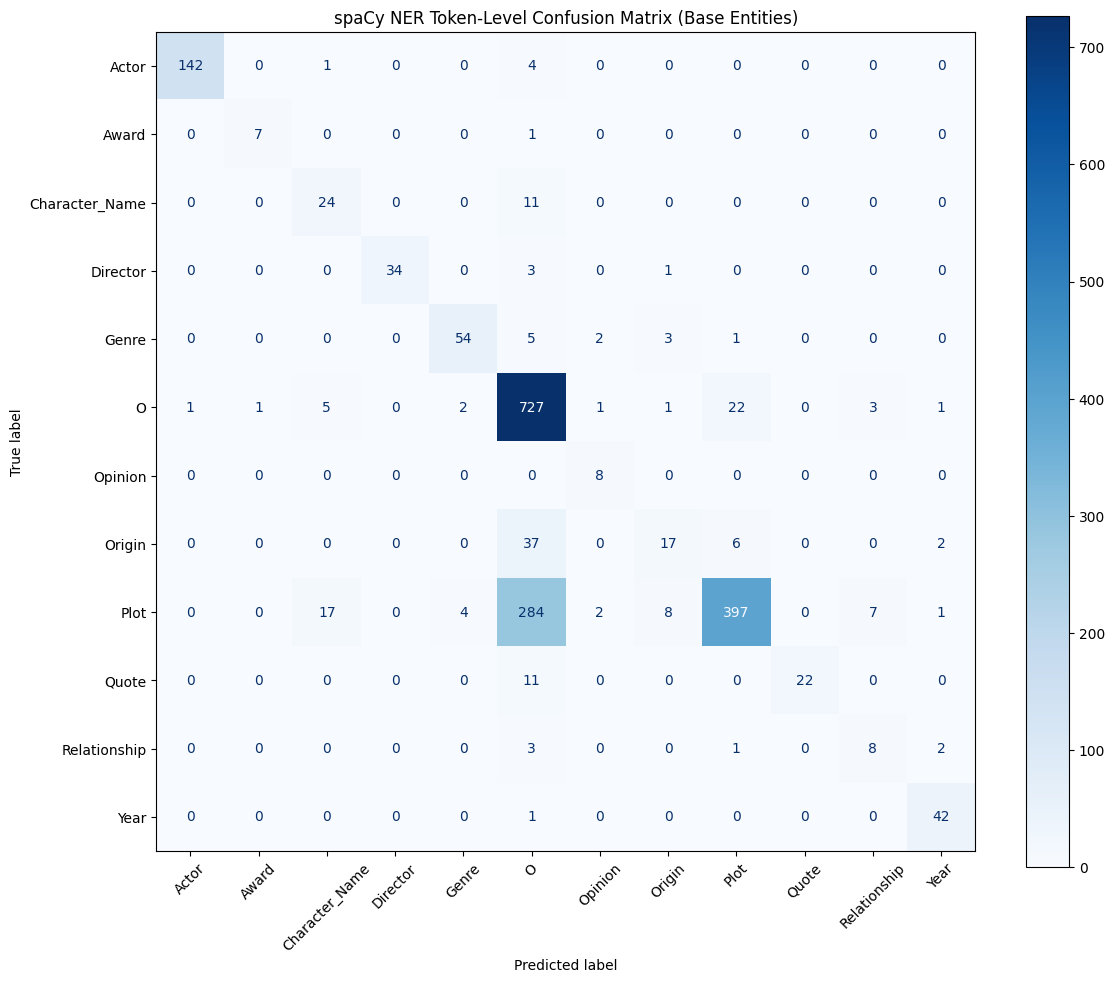

In [151]:
# 1. Create the Example objects for spaCy
print("Preparing examples for CoT (Multi-Turn) evaluation...")
cot_examples = create_ner_examples_for_spacy_scorer(
    ground_truth_docs=ground_truth_docs,
    predicted_docs=cot_predictions
)

# 2. Entity-Level Evaluation (Scorer)
print("\n=========================================")
print("  COT (MULTI-TURN) ENTITY-LEVEL EVALUATION  ")
print("=========================================")
cot_evaluation_scores = score_ner_examples(examples=cot_examples)

# 3. Token-Level Evaluation (Confusion Matrix)
print("\n=========================================")
print("   COT (MULTI-TURN) TOKEN-LEVEL EVALUATION  ")
print("=========================================")
calculate_ner_confusion_matrix(examples=cot_examples)

In [152]:
# Calculate the percentage of successful queries (no exceptions) for CoT
total_queries = len(cot_predictions)
successful_queries = sum(1 for p in cot_predictions if not (hasattr(p, 'exception') and p.exception is not None))
failed_queries = total_queries - successful_queries

success_rate = (successful_queries / total_queries) * 100

print(f"Total Queries: {total_queries}")
print(f"Successful Queries: {successful_queries}")
print(f"Failed Queries (with exceptions): {failed_queries}")
print(f"Success Rate: {success_rate:.2f}%")


Total Queries: 100
Successful Queries: 94
Failed Queries (with exceptions): 6
Success Rate: 94.00%


## Experiment Summary

The following tables summarize the performance of the various Named Entity Recognition (NER) prompting techniques tested:

1.  **Zero-Shot**: No examples provided.
2.  **One-Shot**: A single relevant example provided.
3.  **Few-Shot (n=5)**: Up to 5 relevant examples provided.
4.  **Few-Shot (n=10)**: Up to 10 relevant examples provided.
5.  **Few-Shot (n=20)**: Up to 20 relevant examples provided.
6.  **Chain-of-Thought (Multi-Turn)**: Iterative entity extraction prompting using up to 5 examples.

The tables below display both **Entity-Level** (exact span matches) and **Token-Level** (individual word tag matches) performance metrics (Precision, Recall, and F1 Score).

In [153]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
from spacy.training import offsets_to_biluo_tags

# Define the experiments list using the variables stored in the environment
experiments = [
    {"Num": 1, "Label": "Zero-Shot", "Shots": 0, "Scores": zero_shot_evaluation_scores, "Examples": zero_shot_examples},
    {"Num": 2, "Label": "One-Shot", "Shots": 1, "Scores": one_shot_evaluation_scores, "Examples": one_shot_examples},
    {"Num": 3, "Label": "Few-Shot (n=5)", "Shots": 5, "Scores": few_shot_evaluation_scores, "Examples": few_shot_examples},
    {"Num": 4, "Label": "Few-Shot (n=10)", "Shots": 10, "Scores": few_shot_10_evaluation_scores, "Examples": few_shot_10_examples},
    {"Num": 5, "Label": "Few-Shot (n=20)", "Shots": 20, "Scores": few_shot_20_evaluation_scores, "Examples": few_shot_20_examples},
    {"Num": 6, "Label": "Chain-of-Thought (Multi-Turn)", "Shots": 5, "Scores": cot_evaluation_scores, "Examples": cot_examples}
]

entity_data = []
token_data = []

def strip_prefix(tag):
    return tag.split('-', 1)[1] if '-' in tag else tag

for exp in experiments:
    # Extract Entity-Level Scores
    entity_data.append({
        "Experiment #": exp["Num"],
        "Experiment Label": exp["Label"],
        "# of Samples (Shots)": exp["Shots"],
        "Precision": exp["Scores"]["ents_p"],
        "Recall": exp["Scores"]["ents_r"],
        "F1 Score": exp["Scores"]["ents_f"]
    })

    # Re-calculate Token-Level weighted scores based on the confusion matrix logic
    raw_y_true = []
    raw_y_pred = []
    for example in exp["Examples"]:
        doc_gold = example.reference
        doc_pred = example.predicted
        gold_entities = [(ent.start_char, ent.end_char, ent.label_) for ent in doc_gold.ents]
        pred_entities = [(ent.start_char, ent.end_char, ent.label_) for ent in doc_pred.ents]

        gold_bilou_tags = offsets_to_biluo_tags(doc_gold, gold_entities)
        pred_bilou_tags = offsets_to_biluo_tags(doc_pred, pred_entities)

        if len(gold_bilou_tags) == len(pred_bilou_tags):
            raw_y_true.extend(gold_bilou_tags)
            raw_y_pred.extend(pred_bilou_tags)

    y_true = [strip_prefix(t) for t in raw_y_true]
    y_pred = [strip_prefix(t) for t in raw_y_pred]

    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    token_data.append({
        "Experiment #": exp["Num"],
        "Experiment Label": exp["Label"],
        "# of Samples (Shots)": exp["Shots"],
        "Precision": p,
        "Recall": r,
        "F1 Score": f
    })

df_entity = pd.DataFrame(entity_data)
df_token = pd.DataFrame(token_data)

print("--- Entity-Level Accuracy ---")
display(df_entity.round(3))

print("\n--- Token-Level Accuracy (Weighted) ---")
display(df_token.round(3))


--- Entity-Level Accuracy ---


,Experiment #,Experiment Label,# of Samples (Shots),Precision,Recall,F1 Score
0,1,Zero-Shot,0,0.585,0.416,0.486
1,2,One-Shot,1,0.614,0.641,0.627
2,3,Few-Shot (n=5),5,0.603,0.638,0.620
3,4,Few-Shot (n=10),10,0.665,0.691,0.678
4,5,Few-Shot (n=20),20,0.658,0.678,0.668
5,6,Chain-of-Thought (Multi-Turn),5,0.663,0.648,0.655



--- Token-Level Accuracy (Weighted) ---


,Experiment #,Experiment Label,# of Samples (Shots),Precision,Recall,F1 Score
0,1,Zero-Shot,0,0.666,0.551,0.468
1,2,One-Shot,1,0.790,0.736,0.721
2,3,Few-Shot (n=5),5,0.826,0.785,0.782
3,4,Few-Shot (n=10),10,0.837,0.813,0.813
4,5,Few-Shot (n=20),20,0.862,0.843,0.845
5,6,Chain-of-Thought (Multi-Turn),5,0.808,0.765,0.756
